# Depression and MentalHealth Classification



## Load Dataset

First, the required Python libraries were imported, followed by loading the dataset into the environment. To understand the structure of the data, the first 10 rows were displayed using the head() function. The preview showed that all variables in the dataset are categorical, and according to the dataset description, these features were already encoded by the original authors.

In [ ]:
# Import the neccessary libraries
import pandas as pd # DataFrames, loading and cleaning data
import numpy as np  # Numerical operations

import matplotlib.pyplot as plt # For data visualization (plots, graphs)
import seaborn as sns  # For advanced and visually appealing statistical plots

# Model training and validation
from sklearn.model_selection import train_test_split, cross_val_score 
# train_test_split → split data
# cross_val_score → cross-validation

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Model evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)

# Preprocessing and pipeline
from sklearn.preprocessing import StandardScaler # StandardScaler → normalizes/standardizes features for ML models
from sklearn.pipeline import Pipeline # StandardScaler → normalizes/standardizes features for ML models
import joblib # Saving/loading trained models
import warnings
warnings.filterwarnings('ignore') # Hide warnings

print("All libraries are successfully downloaded")

All libraries are successfully downloaded


In [2]:
#Load the data with pandas as pd
data = pd.read_csv('Mental Health Classification.csv')
data.head(10).T #print first 10 row of the dataset

,0,1,2,3,4,5,6,7,8,9
Gender,1,1,1,0,1,1,1,1,1,1
Age,25,25,25,25,25,25,25,25,25,25
Education_Level,2,2,2,2,2,2,2,1,2,3
Employment_Status,3,2,3,2,2,2,4,2,2,0
Depression_Type,5,5,2,6,6,9,9,4,11,2
Symptoms,11,0,5,7,5,1,5,3,14,5
Low_Energy,1,1,1,0,0,1,1,1,0,1
Low_SelfEsteem,1,1,1,1,0,0,1,1,0,0
Search_Depression_Online,1,0,1,0,0,0,0,1,0,0
Worsening_Depression,1,1,1,1,0,1,1,1,0,0


In [3]:
data.info() #print information of the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1998 entries, 0 to 1997
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Gender                    1998 non-null   int64
 1   Age                       1998 non-null   int64
 2   Education_Level           1998 non-null   int64
 3   Employment_Status         1998 non-null   int64
 4   Depression_Type           1998 non-null   int64
 5   Symptoms                  1998 non-null   int64
 6   Low_Energy                1998 non-null   int64
 7   Low_SelfEsteem            1998 non-null   int64
 8   Search_Depression_Online  1998 non-null   int64
 9   Worsening_Depression      1998 non-null   int64
 10  Your overeating level     1998 non-null   int64
 11  How many times you eat    1998 non-null   int64
 12  SocialMedia_Hours         1998 non-null   int64
 13  SocialMedia_WhileEating   1998 non-null   int64
 14  Sleep_Hours               1998 non-null 

## Data Preparation

Next, I examined the data types of all columns to confirm that the encoding was applied correctly. I also checked for missing values, and the results indicated that the dataset contains no null values.  I reviewed the dataset's shape.

Finally, duplicate records were also inspected, and none were found, confirming that the dataset is clean and consistent. I reviewed the column names. To improve readability and ensure compatibility during analysis, the column names were standardized by replacing spaces with underscores (_).

In [4]:
#checking null values or missing values. If it is False, it doesn't have any missing values or NULL values
data.isnull().sum()

Gender                      0
Age                         0
Education_Level             0
Employment_Status           0
Depression_Type             0
Symptoms                    0
Low_Energy                  0
Low_SelfEsteem              0
Search_Depression_Online    0
Worsening_Depression        0
Your overeating level       0
How many times you eat      0
SocialMedia_Hours           0
SocialMedia_WhileEating     0
Sleep_Hours                 0
Nervous_Level               0
Depression_Score            0
Coping_Methods              0
Self_Harm                   0
Mental_Health_Support       0
Suicide_Attempts            0
dtype: int64

In [5]:
data.shape #print shape of the data which instances and features

(1998, 21)

In [6]:
data.duplicated() #Check the duplicate data.If there is any duplicate data, it shows True result.

0       False
1       False
2       False
3       False
4       False
        ...  
1993    False
1994    False
1995    False
1996    False
1997    False
Length: 1998, dtype: bool

In [7]:
for col in data.columns:
    print(repr(col))

'Gender'
'Age'
'Education_Level'
'Employment_Status'
'Depression_Type'
'Symptoms'
'Low_Energy'
'Low_SelfEsteem'
'Search_Depression_Online'
'Worsening_Depression'
'Your overeating level'
'How many times you eat '
'SocialMedia_Hours'
'SocialMedia_WhileEating'
'Sleep_Hours'
'Nervous_Level'
'Depression_Score'
'Coping_Methods'
'Self_Harm'
'Mental_Health_Support'
'Suicide_Attempts'


In [8]:
data.columns = (
    data.columns
        .str.strip()
        .str.replace(" ", "_")
        .str.replace("/", "_")
)
for col in data.columns:
    print(repr(col))

'Gender'
'Age'
'Education_Level'
'Employment_Status'
'Depression_Type'
'Symptoms'
'Low_Energy'
'Low_SelfEsteem'
'Search_Depression_Online'
'Worsening_Depression'
'Your_overeating_level'
'How_many_times_you_eat'
'SocialMedia_Hours'
'SocialMedia_WhileEating'
'Sleep_Hours'
'Nervous_Level'
'Depression_Score'
'Coping_Methods'
'Self_Harm'
'Mental_Health_Support'
'Suicide_Attempts'


## EDA analysis for categorical features

The dataset contains 21 features, of which 4 are numerical and 17 are categorical. For clarity, the EDA process was divided into two groups: numerical features and categorical features.

I first analyzed the numerical features. Using the describe() function, I generated summary statistics to understand the central tendency and variability of each variable. Next, I examined the distribution of each numerical feature through histograms and checked for potential outliers using boxplots. Finally, I computed and visualized the correlation matrix to identify relationships between numerical variables.

In [10]:
#EDA analysis for numerical columns of the data. 
# It shows, count, mean, std(standard deviation), min, max, and quartiles.
num_cols = [
    "Depression_Score",
    "SocialMedia_Hours",
    "Sleep_Hours"
]

data[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Depression_Score,1998.0,14.622623,8.948343,0.0,7.0,14.0,22.0,30.0
SocialMedia_Hours,1998.0,5.960961,3.728180,0.0,3.0,6.0,9.0,12.0
Sleep_Hours,1998.0,6.505506,2.278048,3.0,5.0,7.0,8.0,10.0


The dataset contains numerical variables: Depression_Score, SocialMedia_Hours, and Sleep_Hours. Their descriptive statistics provide an initial understanding of central tendency, variability, and distribution. 

-Depression_Score ranges from 0 to 30, with a mean of 14.62, indicating that, on average, participants fall in the mid-level range of depressive symptoms. The relatively high standard deviation (8.95) suggests significant variability in depression severity across respondents.

-SocialMedia_Hours has a mean of 5.96 hours per day, with values ranging from 0 to 12 hours. The wide spread (std = 3.73) shows that social media usage varies substantially among participants, which may influence mental-health outcomes.

-Sleep_Hours averages 6.50 hours, with a minimum of 3 hours and a maximum of 10 hours. The interquartile range (5–8 hours) indicates that most respondents sleep within a typical range, though some may experience insufficient sleep, which is often linked to mental-health issues.

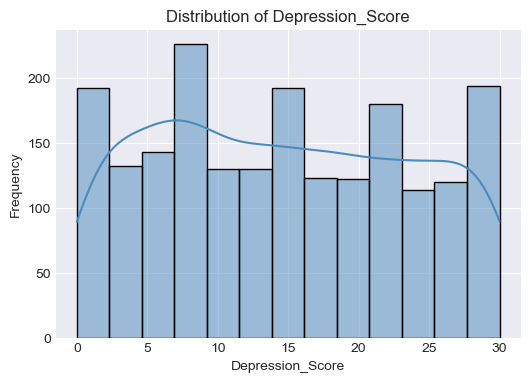

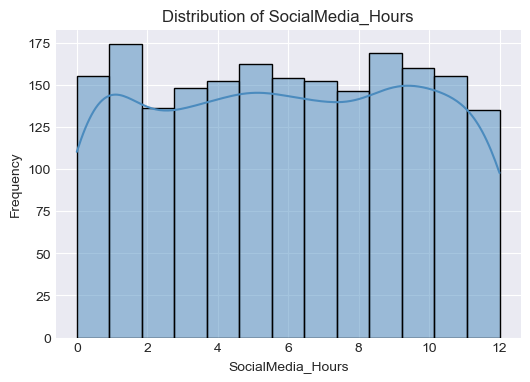

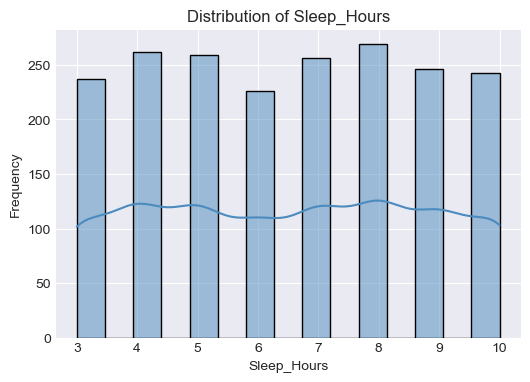

In [11]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(data[col], kde=True, color="#4B8BBE")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

There are no extreme outliers in the numerical features Depression_Score, SocialMedia_Hours, and Sleep_Hours, which display a broad and balanced distribution. The dataset's low, moderate, and high symptom levels are indicated by depression scores, which range from 0 to 30. The range of SocialMedia_Hours, which ranges from 0 to 12 hours, reflects the respondents' varied usage habits. The majority of participants fall within a typical sleep range, which spans from three to ten hours.

All things considered, the boxplots and distributions validate clean data and good variability across all three variables, which makes them instructive and appropriate for more research and predictive modeling.

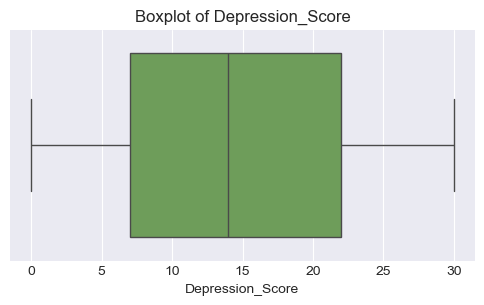

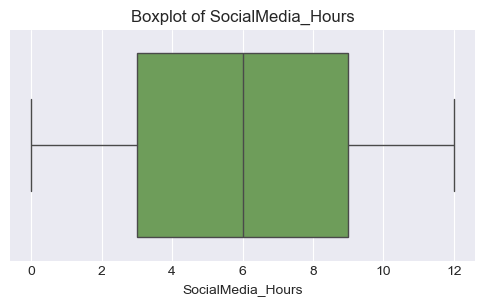

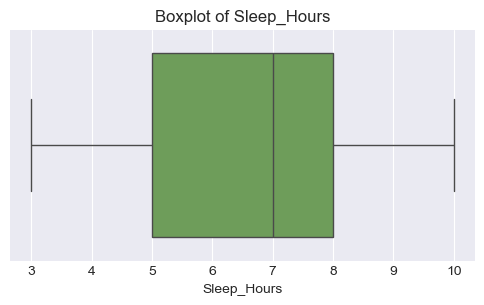

In [12]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=data[col], color="#6AA84F")
    plt.title(f"Boxplot of {col}")
    plt.show()

The boxplot of Depression_Score shows that scores are widely distributed between 0 and 30, with no extreme outliers. The median lies around the mid-range, indicating that most participants experience moderate levels of depressive symptoms.

For SocialMedia_Hours, the values range from 0 to 12 hours, with the middle 50% of respondents using social media between approximately 4 and 9 hours per day. The distribution is fairly broad, suggesting diverse usage patterns.

The Sleep_Hours boxplot shows a range between 3 and 10 hours, with the median around 7 hours. This indicates that most participants fall within a normal sleep range, and there are no extreme deviations.

Overall, all three boxplots indicate wide but reasonable variation, with no significant outliers, making these features reliable and useful for further modelling.

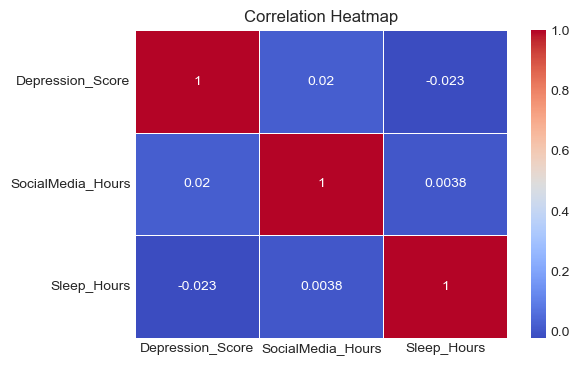

In [13]:
corr = data[num_cols].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap shows that the numerical features have very weak relationships with each other. Depression_Score has near-zero correlation with both SocialMedia_Hours (0.02) and Sleep_Hours (–0.023), indicating that neither variable has a strong linear connection with depression levels. Similarly, SocialMedia_Hours and Sleep_Hours also show almost no correlation (0.0038). Overall, the numerical features appear to be largely independent.

#### EDA analysis for Categorical features

The dataset contains 17 categorical variables, which I divided into three groups (each containing six variables) for clearer visualization and interpretation. For each group, I plotted the categorical distributions and calculated the percentage frequencies to understand how the categories are represented across the dataset.

Age originally comprised continuous numerical values. For easy of interpretation, it was categorized by age groups and examined as a categorical variable. 

To assess statistical relationships, I performed a Chi-square test for each categorical feature and marked whether the association with the target variable (Depression_Type) was significant or not. Based on these results, I selected the most important categorical predictors for further analysis.

Next, I visualized the distribution of these selected features by comparing them directly with the target variable. Finally, to measure the strength of association between categorical variables, I computed a Cramer's V correlation matrix, which helped identify the most influential categorical factors contributing to depression type classification.

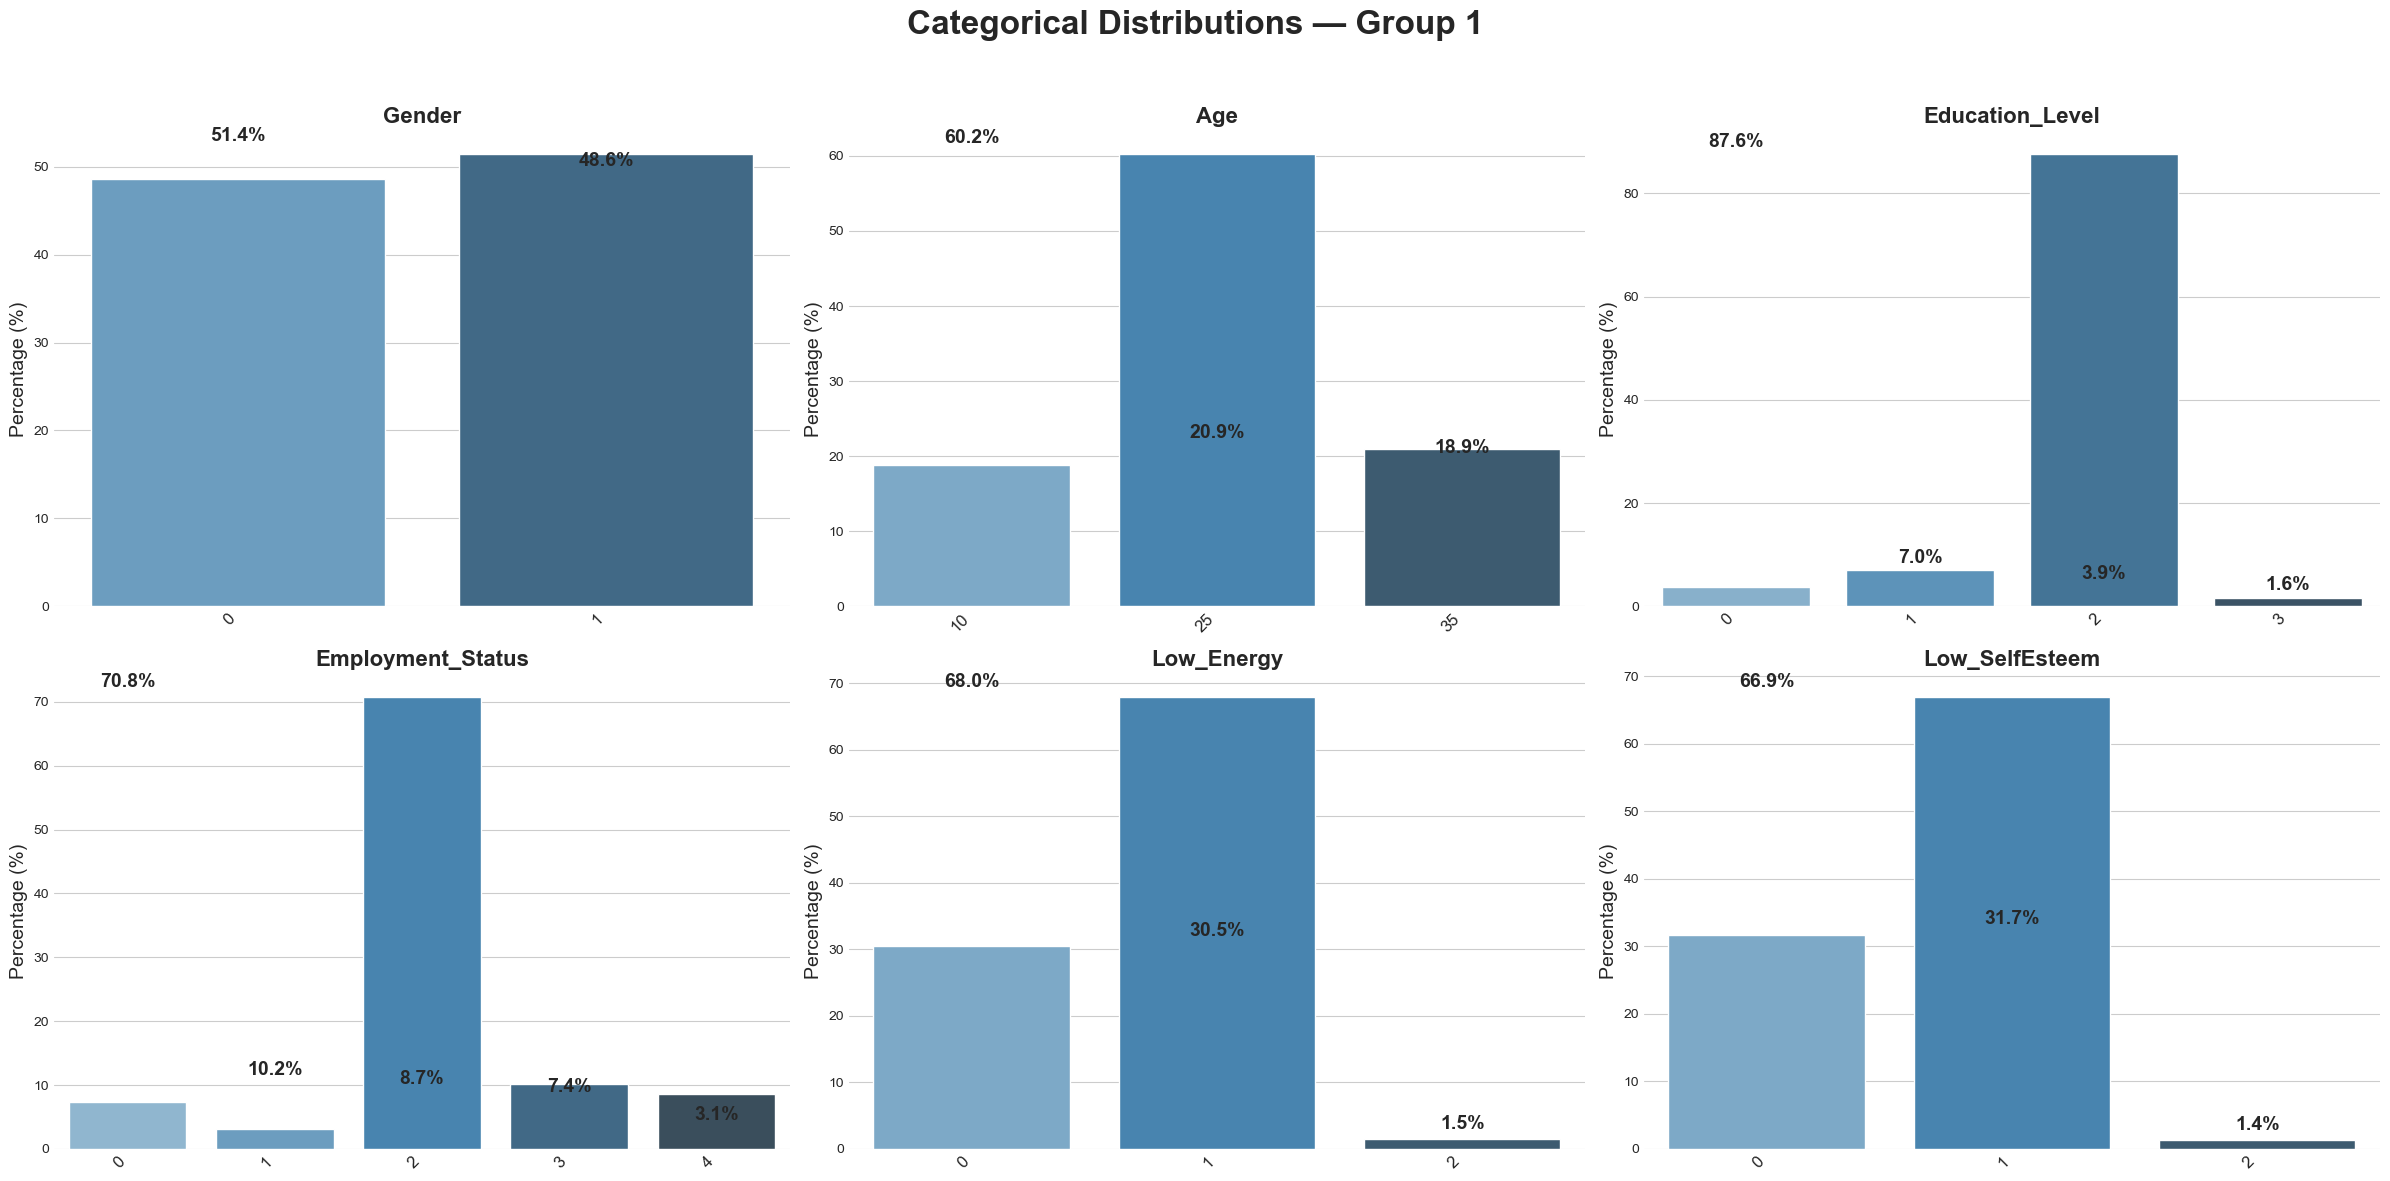

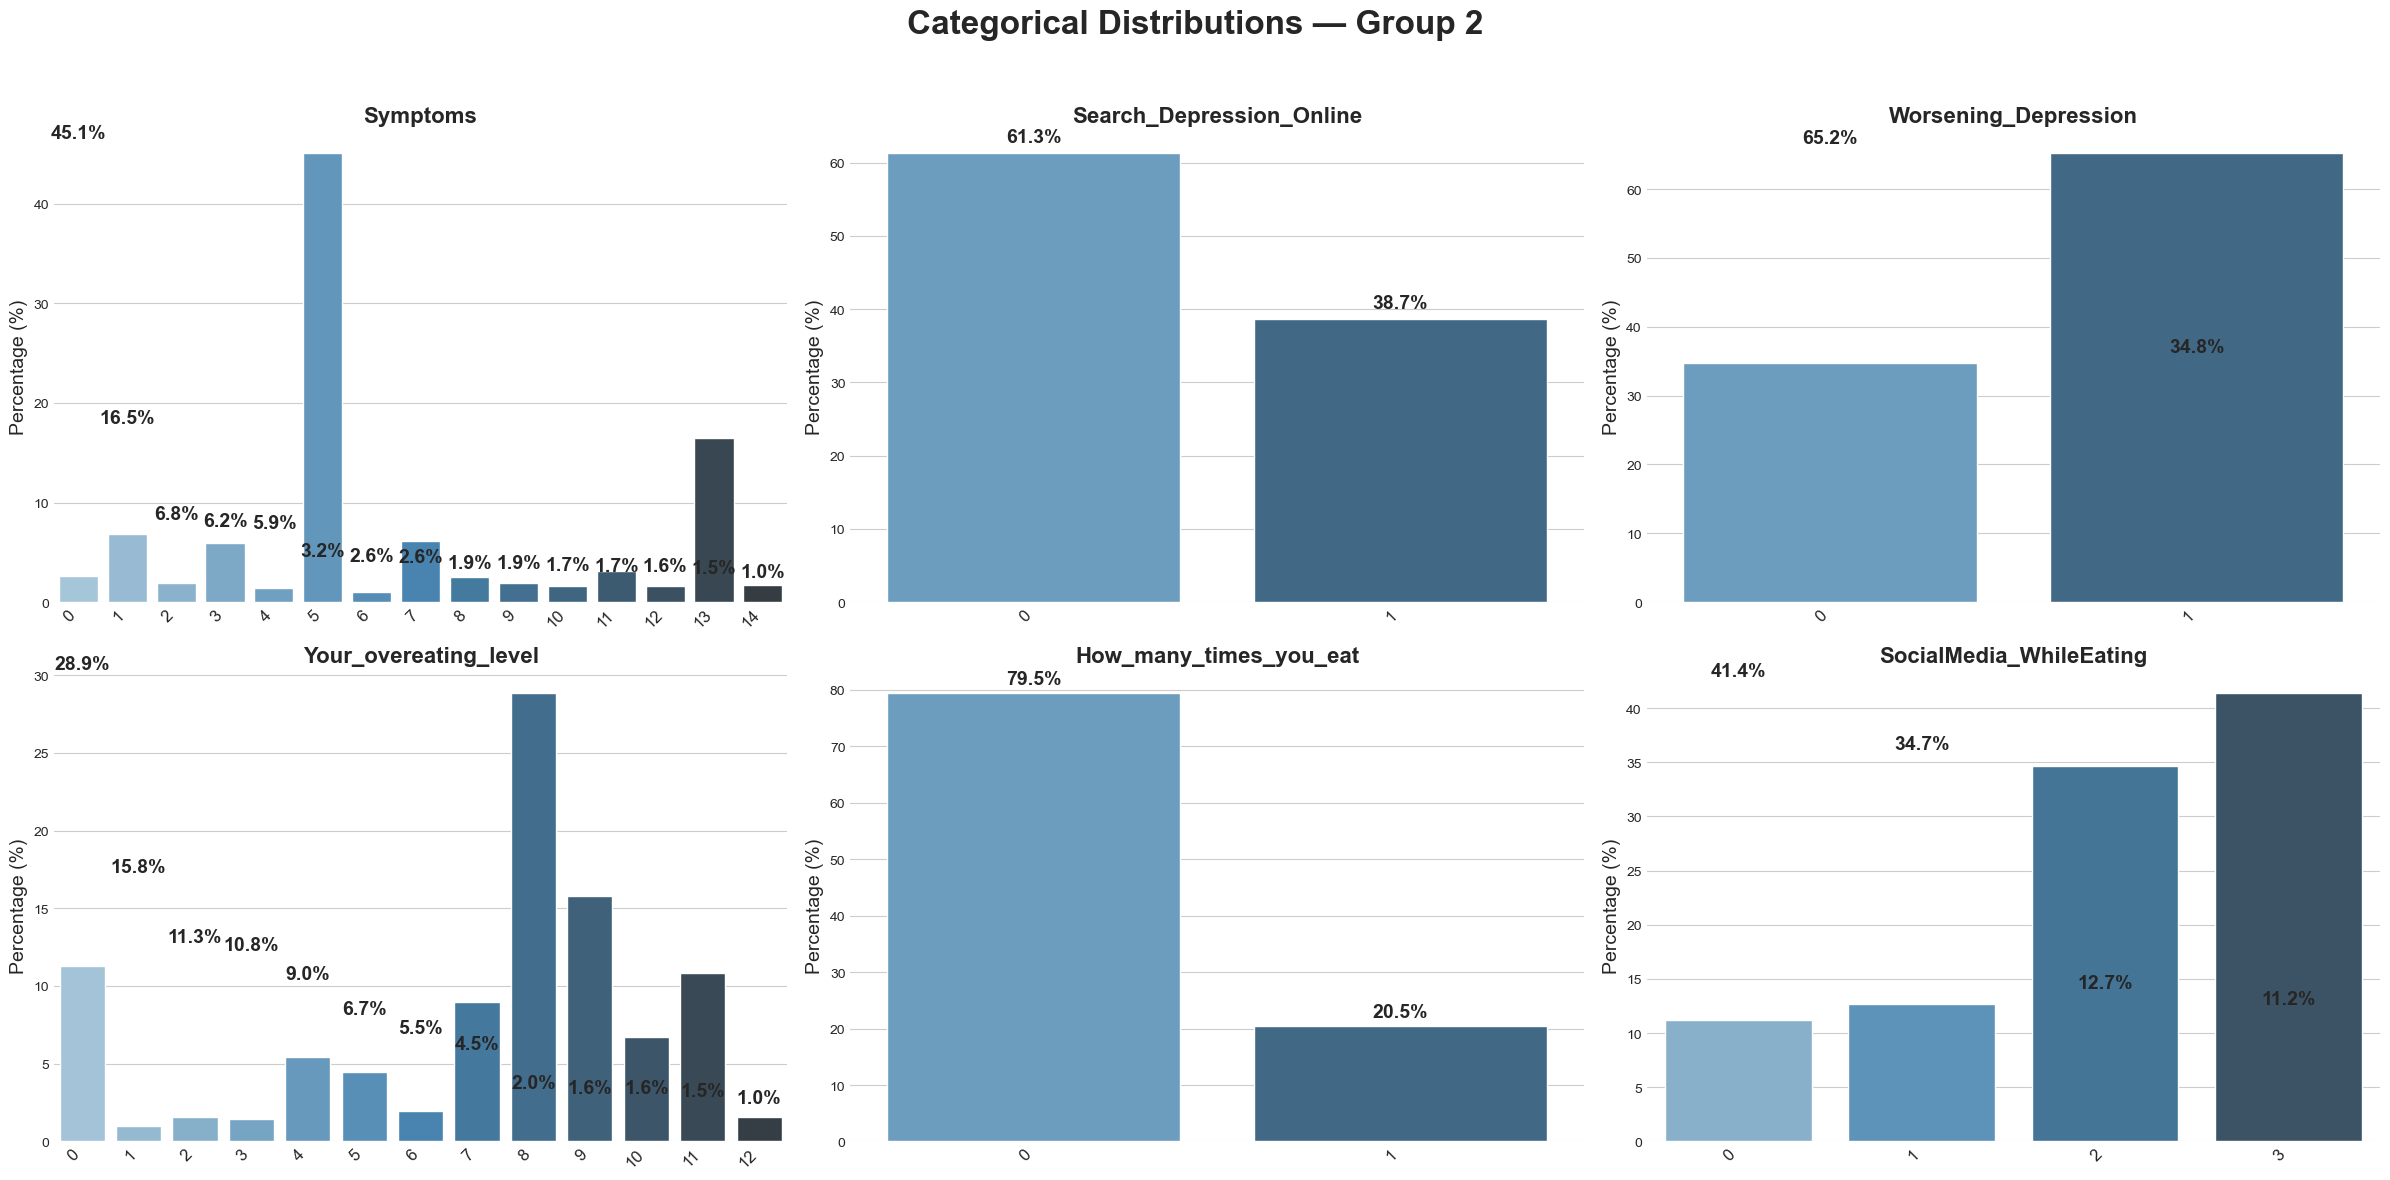

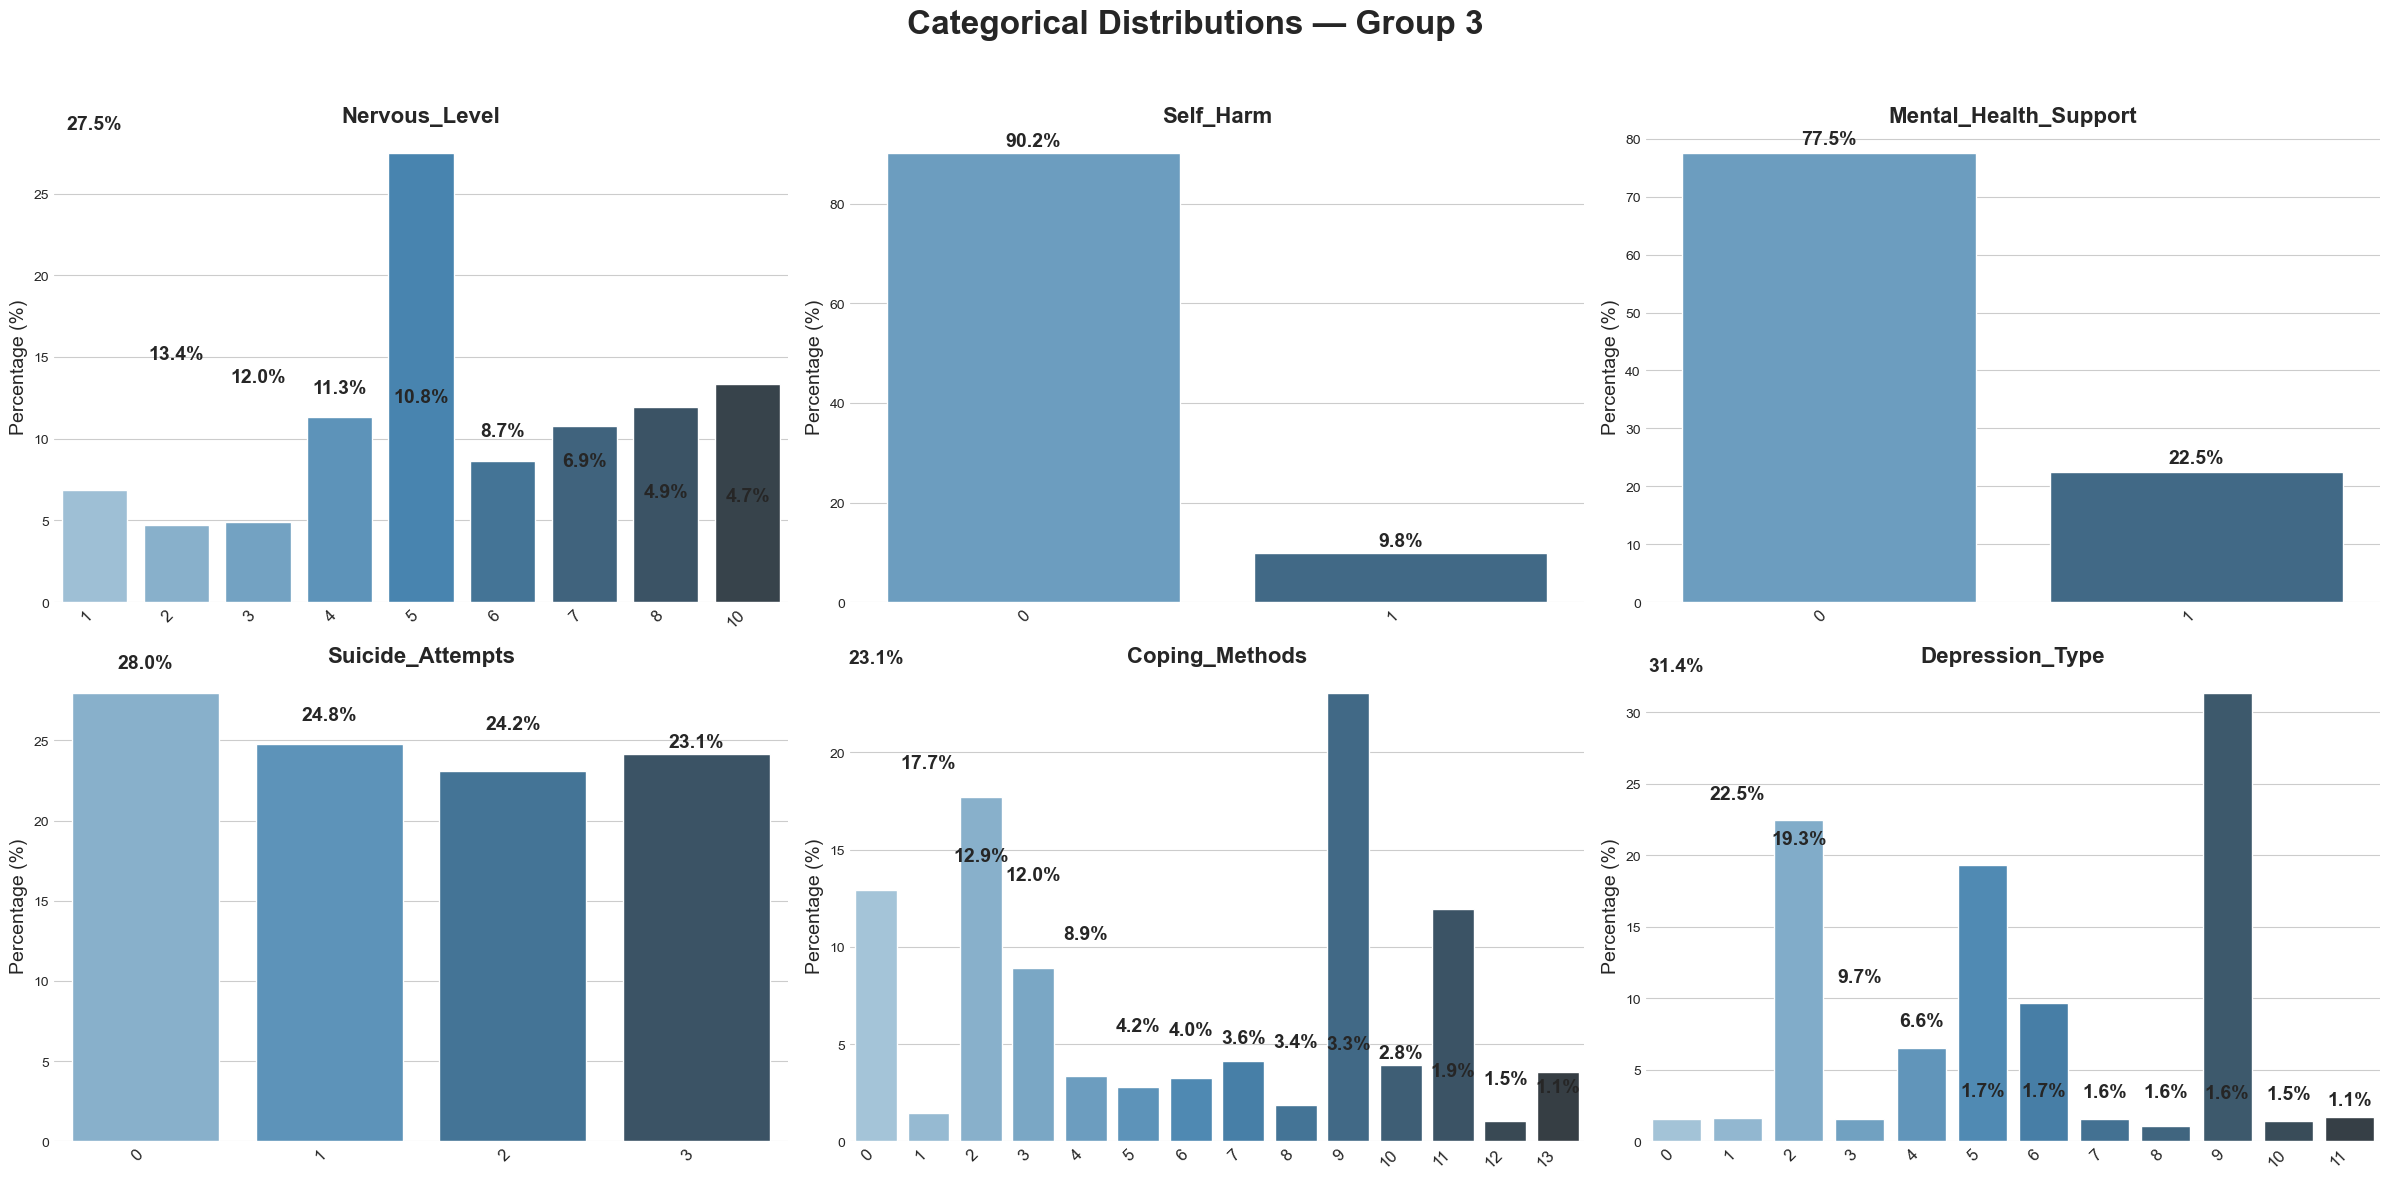

In [14]:
sns.set_style("whitegrid")

categoric_cols = [
    "Gender",
    "Age",
    "Education_Level",
    "Employment_Status",
    "Low_Energy",
    "Low_SelfEsteem",
    "Symptoms",
    "Search_Depression_Online",
    "Worsening_Depression",
    "Your_overeating_level",
    "How_many_times_you_eat",
    "SocialMedia_WhileEating",
    "Nervous_Level",
    "Self_Harm",
    "Mental_Health_Support",
    "Suicide_Attempts",
    "Coping_Methods", 
    "Depression_Type",
]

group_size = 6
total_groups = (len(categoric_cols) + group_size - 1) // group_size

for g in range(total_groups):
    start = g * group_size
    end = start + group_size
    subset_cols = categoric_cols[start:end]

    plt.figure(figsize=(24, 12))
    plt.suptitle(f"Categorical Distributions — Group {g+1}", fontsize=24, weight="bold")

    for i, col in enumerate(subset_cols, 1):
        plt.subplot(2, 3, i)

        counts = data[col].value_counts(normalize=True) * 100
        
        sns.barplot(x=counts.index, y=counts.values, palette="Blues_d")

        plt.title(col, fontsize=16, weight="bold")
        plt.ylabel("Percentage (%)", fontsize=14)
        plt.xlabel("")

        plt.xticks(rotation=45, ha='right', fontsize=12)

        # Bar ustiga katta foiz yozish
        for idx, val in enumerate(counts.values):
            plt.text(idx, val + 1.5, f"{val:.1f}%", 
                     ha='center', fontsize=14, weight="bold")

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


Gender is virtually balanced, however the age distribution is predominantly characterized by the middle-aged category. Age originally comprised continuous numerical values. For easy of interpretation, it was categorized by age groups and examined as a categorical variable. The Education_Level and Employment_Status variables exhibit significant concentration in a singular category, signifying restricted variability in these attributes. A majority of respondents express symptoms of both Low potentially influencing their predictive role in classifiying types of depression.

Symptoms, Search_Depression_Online, Worsening_Depression, Overeating, How_often_eat, and SocialMedia_WhileEating are in Group 2. Category dominance is evident in various variable distributions. Symptoms are extremely unbalanced, with category 5 accounting for most reactions. Most individuals do not search for depression material online, but most report worsening depression symptoms. Skewed eating frequency: roughly 80% fit into group 0. Overeating and social media use while eating have unequal distributions, suggesting heterogeneous responder behaviour. Group 2 has various behavior- and symptom-related factors with high category concentrations that may predict depression type.

In this diagram, Nervous_Level is distributed throughout categories but peaks at category 5, suggesting respondents' anxiety levels. With 90% reporting no self-harm, Self_Harm is significantly unbalanced. 77.5% of individuals report not obtaining Mental_Health_Support. Suicide_Attempts has an equitable distribution across four categories, reflecting different sample experiences. Coping_Methods has several tactics, but few dominate. Depression_Type shows a considerable imbalance, with some depression types more common.This visualization has a mix of highly skewed and moderately dispersed traits, many of which describe depression-related psychological and behavioral aspects.

In [15]:
from scipy.stats import chi2_contingency

results = []

for col in categoric_cols:
    table = pd.crosstab(data[col], data["Depression_Type"])
    p_value = chi2_contingency(table)[1]
    significance = "Significant" if p_value < 0.05 else "Not Significant"
    
    results.append({
        "Feature": col,
        "p-value": p_value,
        "Significant?": significance
    })
chi_table = pd.DataFrame(results)
chi_table["p-value"] = chi_table["p-value"].apply(lambda x: f"{x:.3e}")
chi_table

,Feature,p-value,Significant?
0,Gender,5.089e-01,Not Significant
1,Age,9.099e-01,Not Significant
2,Education_Level,1.344e-218,Significant
3,Employment_Status,0.000e+00,Significant
4,Low_Energy,1.583e-138,Significant
5,Low_SelfEsteem,1.328e-74,Significant
6,Symptoms,0.000e+00,Significant
7,Search_Depression_Online,7.522e-69,Significant
8,Worsening_Depression,1.483e-57,Significant
9,Your_overeating_level,0.000e+00,Significant


Most categorical characteristics are statistically associated with Depression_Type, according to the Chi-square test. Thus, education, self-esteem, low energy, symptom intensity, dietary habits, and mental-health behaviors vary significantly across depression categories. Gender, Age, and Suicide_Attempts are the only factors that do not significantly differentiate depression kinds.These results identify the categorization model's most important categorical predictors

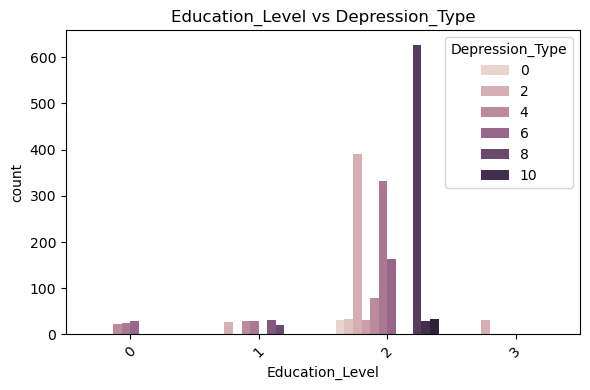

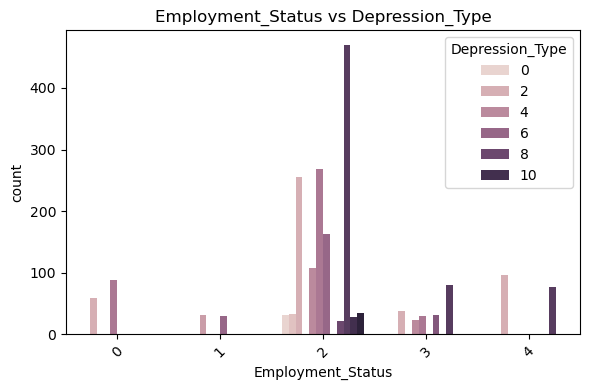

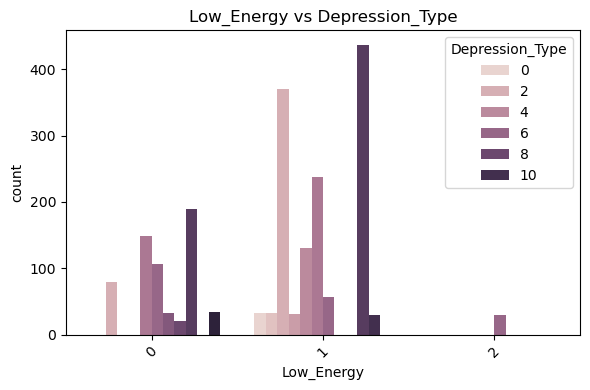

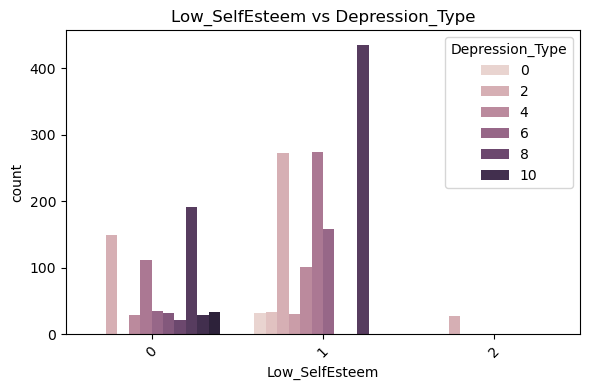

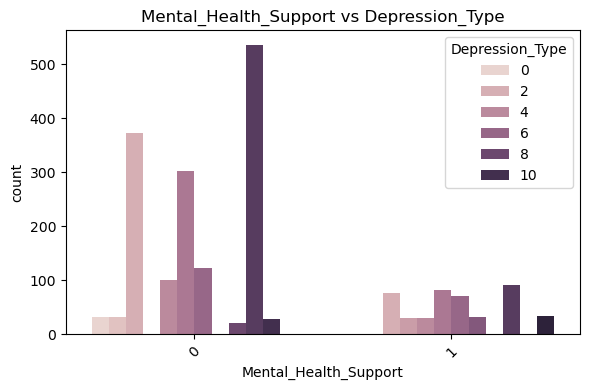

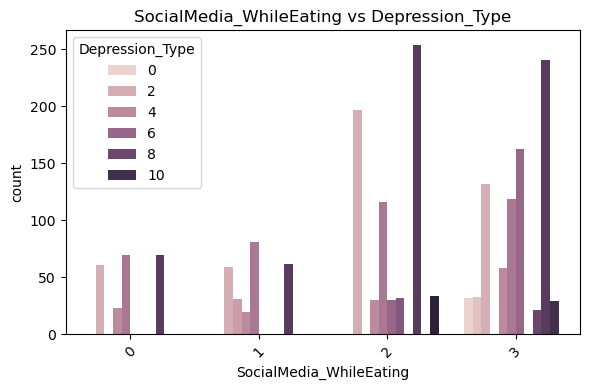

In [9]:
top_categoric = [
    "Education_Level", "Employment_Status", "Low_Energy",
    "Low_SelfEsteem", "Mental_Health_Support", "SocialMedia_WhileEating" ]

for col in top_categoric:
    plt.figure(figsize=(6,4))
    sns.countplot(data=data, x=col, hue="Depression_Type")
    plt.xticks(rotation=45)
    plt.title(f"{col} vs Depression_Type")
    plt.tight_layout()
    plt.show()


Relationship Between Selected Categorical Features and Depression Type

 To investigate the Chi-square test's important predictors, major categorical features were compared to Depression_Type.

 Education_Level indicates a high concentration in category 2 across most depression categories, suggesting that education may affect depression.

 Employment_Status also shows variance, with certain work types showing more often in different depression groups, suggesting occupational conditions may affect depression type.

 Higher levels of Low_Energy and Low_SelfEsteem are connected with more severe depression categories, highlighting their value as behavioral indicators.

 Most Mental_Health_Support respondents who do not receive support fall into many main depression categories, suggesting that lack of support may lead to more persistent or severe depression.

 SocialMedia_WhileEating shows distinct distribution patterns among depression types, suggesting that lifestyle choices may vary by depression type.

 These visual comparisons show significant behavioral, emotional, and lifestyle variations amongst depression groups, validating their classification predictiveness.

In [10]:
# List of categorical columns you want to analyze with crosstab
cols_to_check = [
    "Education_Level",
    "Employment_Status",
    "Low_Energy",
    "Low_SelfEsteem",
    "SocialMedia_WhileEating"
]

# Function for printing nicely formatted crosstabs
def print_crosstab(col):
    print(f"\n\n===== {col} vs Depression_Type (Percentage %) =====\n")
    table = pd.crosstab(data[col], data["Depression_Type"], normalize="index") * 100
    display(table.round(2))   # rounded to 2 decimals for clarity

# Loop through all columns
for col in cols_to_check:
    print_crosstab(col)



===== Education_Level vs Depression_Type (Percentage %) =====



Depression_Type,0,1,2,3,4,5,6,7,8,9,10,11
Education_Level,,,,,,,,,,,,
0,0.00,0.00,0.00,0.00,29.87,31.17,38.96,0.00,0.00,0.00,0.00,0.00
1,0.00,0.00,19.42,0.00,20.86,21.58,0.00,23.02,15.11,0.00,0.00,0.00
2,1.83,1.89,22.29,1.77,4.51,18.97,9.31,0.00,0.00,35.83,1.66,1.94
3,0.00,0.00,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00




===== Employment_Status vs Depression_Type (Percentage %) =====



Depression_Type,0,1,2,3,4,5,6,7,8,9,10,11
Employment_Status,,,,,,,,,,,,
0,0.00,0.00,40.14,0.00,0.00,59.86,0.00,0.00,0.00,0.00,0.00,0.0
1,0.00,0.00,0.00,50.82,0.00,0.00,49.18,0.00,0.00,0.00,0.00,0.0
2,2.26,2.33,18.10,0.00,7.64,18.95,11.53,0.00,1.49,33.24,2.05,2.4
3,0.00,0.00,18.72,0.00,11.33,14.78,0.00,15.76,0.00,39.41,0.00,0.0
4,0.00,0.00,55.49,0.00,0.00,0.00,0.00,0.00,0.00,44.51,0.00,0.0




===== Low_Energy vs Depression_Type (Percentage %) =====



Depression_Type,0,1,2,3,4,5,6,7,8,9,10,11
Low_Energy,,,,,,,,,,,,
0,0.00,0.00,12.95,0.00,0.00,24.26,17.38,5.25,3.44,31.15,0.00,5.57
1,2.36,2.43,27.25,2.28,9.65,17.53,4.20,0.00,0.00,32.18,2.14,0.00
2,0.00,0.00,0.00,0.00,0.00,0.00,100.00,0.00,0.00,0.00,0.00,0.00




===== Low_SelfEsteem vs Depression_Type (Percentage %) =====



Depression_Type,0,1,2,3,4,5,6,7,8,9,10,11
Low_SelfEsteem,,,,,,,,,,,,
0,0.00,0.00,23.66,0.00,4.57,17.67,5.52,5.05,3.31,30.28,4.57,5.36
1,2.39,2.47,20.34,2.32,7.63,20.49,11.82,0.00,0.00,32.54,0.00,0.00
2,0.00,0.00,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00




===== SocialMedia_WhileEating vs Depression_Type (Percentage %) =====



Depression_Type,0,1,2,3,4,5,6,7,8,9,10,11
SocialMedia_WhileEating,,,,,,,,,,,,
0,0.00,0.00,27.23,0.00,10.27,31.25,0.00,0.00,0.00,31.25,0.0,0.00
1,0.00,0.00,23.32,12.25,7.91,32.02,0.00,0.00,0.00,24.51,0.0,0.00
2,0.00,0.00,28.43,0.00,4.33,16.74,4.33,4.62,0.00,36.65,0.0,4.91
3,3.86,3.99,15.94,0.00,7.00,14.37,19.69,0.00,2.54,29.11,3.5,0.00


The cross-tabulated percentage tables show how each categorical feature distributes across different depression types. This allows us to identify patterns, dominance, and potential relationships.
| **Feature**                 | **Notable Patterns Across Depression Types**                                  | **Key Interpretation**                                  |
| --------------------------- | ----------------------------------------------------------------------------- | ------------------------------------------------------- |
| **Education_Level**         | Level 2 dominant across Types 4, 5, 6; Level 3 appears only in Type 2         | Strong variation; important predictor                   |
| **Employment_Status**       | Category 2 widespread; Category 0 in Types 4, 5, 6; Category 4 in Types 2 & 9 | Employment differs across depression types              |
| **Low_Energy**              | Category 1 dominant in Types 2, 4, 5, 6, 9; Category 2 only in Type 7         | Low energy strongly linked to specific depression types |
| **Low_SelfEsteem**          | Category 1 common in Types 2, 4, 5, 6, 9; Category 2 only in Type 2           | Self-esteem levels vary significantly across groups     |
| **SocialMedia_WhileEating** | Higher categories (2–3) dominant in Types 5, 9, 10                            | Lifestyle behaviour differs by depression type          |


Analysis of percentage distributions across depression types shows clear behavioural and demographic differences among categories. Education_Level, Employment_Status, Low_Energy, Low_SelfEsteem, and SocialMedia_WhileEating all exhibit strong variation, with specific levels dominating certain depression types. These patterns confirm that these categorical features carry meaningful discriminative power and contribute significantly to classifying depression types.

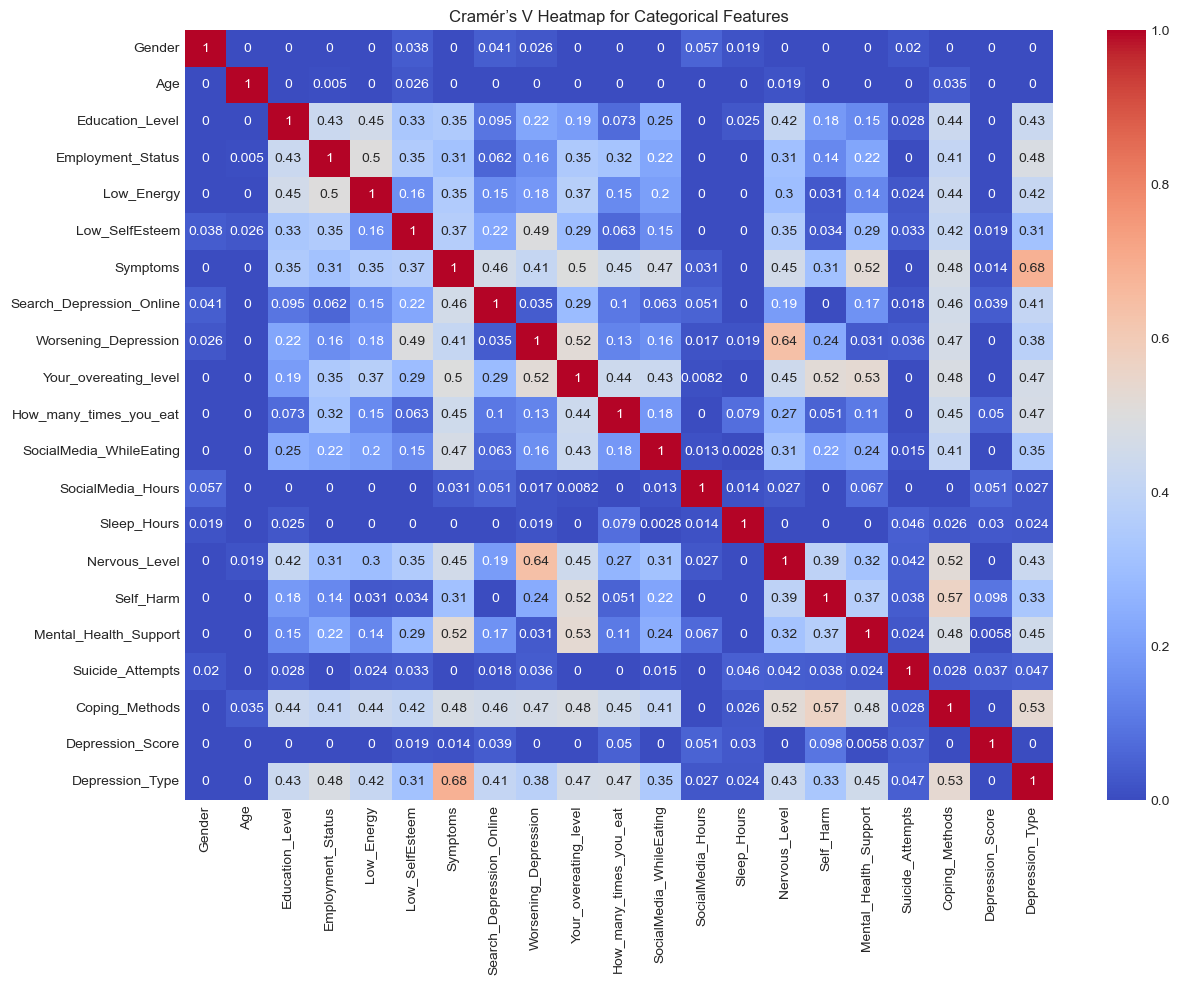

In [18]:
matrix_cols = [
     "Gender",
    "Age",
    "Education_Level",
    "Employment_Status",
    "Low_Energy",
    "Low_SelfEsteem",
    "Symptoms",
    "Search_Depression_Online",
    "Worsening_Depression",
    "Your_overeating_level",
    "How_many_times_you_eat",
    "SocialMedia_WhileEating",
    "SocialMedia_Hours",
    "Sleep_Hours",
    "Nervous_Level",
    "Self_Harm",
    "Mental_Health_Support",
    "Suicide_Attempts",
    "Coping_Methods", 
    "Depression_Score",
    "Depression_Type"
]

def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table)[0]
    n = table.sum().sum()
    phi2 = chi2 / n
    r, k = table.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))
cramer_matrix = pd.DataFrame(index=matrix_cols, columns=matrix_cols)

for col1 in matrix_cols:
    for col2 in matrix_cols:
        cramer_matrix.loc[col1, col2] = cramers_v(data[col1], data[col2])

cramer_matrix = cramer_matrix.astype(float)
plt.figure(figsize=(14, 10))
sns.heatmap(cramer_matrix, annot=True, cmap="coolwarm", vmin=0, vmax=1)
plt.title("Cramér’s V Heatmap for Categorical Features")
plt.show()


Since the dataset contains only categorical features, I used Cramér’s V correlation to measure the strength of association between variables, as it is the most appropriate method for categorical data.
The majority of categorical features exhibit low to moderate correlations, indicating high feature independence and limited multicollinearity, according to the Cramer’S V heatmap. Symptoms, Low Energy, Low Self-Esteem, Worsening Depression, and Coping methods are among the psychological and behavioral factors that exhibit stronger connections and meaningful relationships with Depression_Type. The poor predictive usefulness of demographic characteristics such as gender and age, on the other hand, is confirmed by their extremely weak correlations.

## Models Training

### Logistic Regression

In [12]:
# Optimal feature list
optimal_features = [
    "Low_SelfEsteem",
    "Search_Depression_Online",
    "Self_Harm",
    "SocialMedia_WhileEating",
    "Education_Level",
    "How_many_times_you_eat",
    "Low_Energy",
    "Employment_Status",
    "Mental_Health_Support",
    "Worsening_Depression",
    "Nervous_Level",
    "Symptoms",
    "Coping_Methods",
    "Your_overeating_level",
    "SocialMedia_Hours",
    "Sleep_Hours",
    "Suicide_Attempts",
    "Gender",
    "Depression_Score",
    "Age"
]

X = data[optimal_features]
y = data["Depression_Type"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Optimal Logistic Regression model (ElasticNet)
model = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        max_iter=4000,
        penalty="elasticnet",
        solver="saga",
        l1_ratio=0.5,     # mix of L1 + L2
        class_weight="balanced"
    ))
])

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.67

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         5
           2       0.62      0.66      0.64        88
           3       1.00      1.00      1.00         5
           4       0.68      1.00      0.81        19
           5       0.51      0.34      0.41        86
           6       0.60      1.00      0.75        32
           7       1.00      1.00      1.00         7
           8       1.00      1.00      1.00         4
           9       0.71      0.67      0.69       136
          10       0.90      1.00      0.95         9
          11       1.00      1.00      1.00         5

    accuracy                           0.67       400
   macro avg       0.84      0.89      0.85       400
weighted avg       0.66      0.67      0.66       400



In [15]:
X = data.drop(["Depression_Type"], axis=1)
y = data["Depression_Type"]

model = LogisticRegression(max_iter=2000)
model.fit(X, y)

importance = abs(model.coef_).mean(axis=0)

pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values("Importance", ascending=False)

,Feature,Importance
6,Low_SelfEsteem,1.589352
7,Search_Depression_Online,1.571495
12,SocialMedia_WhileEating,1.325769
17,Self_Harm,1.315329
2,Education_Level,1.284741
10,How_many_times_you_eat,1.194902
5,Low_Energy,1.108263
3,Employment_Status,0.977865
18,Mental_Health_Support,0.868227
8,Worsening_Depression,0.711603


The model identifies Low Self-Esteem, Searching Depression Online, Self-Harm, and SocialMedia While Eating as the most influential predictors of Depression Type, suggesting that emotional state, online searching behavior, and eating-related social media habits strongly differentiate depression categories. Other important factors include eating frequency, education level, low energy, and employment status, which also contribute meaningfully to classification.

In contrast, Age and Depression_Score show extremely low importance, indicating they contribute very little to the model’s predictive performance. Therefore, removing these features is appropriate and should simplify the model without reducing accuracy.

In [17]:
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

optimal_features_last = [
    "Low_SelfEsteem",
    "Search_Depression_Online",
    "Self_Harm",
    "SocialMedia_WhileEating",
    "Education_Level",
    "How_many_times_you_eat",
    "Low_Energy",
    "Employment_Status",
    "Mental_Health_Support",
    "Worsening_Depression",
    "Nervous_Level",
    "Symptoms",
    "Coping_Methods",
    "Your_overeating_level",
    "SocialMedia_Hours",
    "Sleep_Hours",
    "Suicide_Attempts",
    "Gender"
]

X = data[optimal_features_last]
y = data["Depression_Type"]     # 0–11 multiclass

#Test,train split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
#built train model
model = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        max_iter=4000,
        penalty="elasticnet",
        solver="saga",
        l1_ratio=0.5,
        class_weight="balanced",
        multi_class="ovr"
    ))
])

model.fit(X_train, y_train)

#model prediction
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

#metrics accuracy
print("\n===== TRAIN ACCURACY =====")
print(accuracy_score(y_train, y_pred_train))

print("\n===== TEST ACCURACY =====")
print(accuracy_score(y_test, y_pred_test))

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred_test))


===== TRAIN ACCURACY =====
0.6827284105131415

===== TEST ACCURACY =====
0.6875

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         7
           2       0.67      0.69      0.68        90
           3       1.00      1.00      1.00         6
           4       0.60      1.00      0.75        26
           5       0.50      0.34      0.40        77
           6       0.86      0.77      0.81        39
           7       1.00      1.00      1.00         6
           8       1.00      1.00      1.00         4
           9       0.65      0.71      0.68       126
          10       1.00      1.00      1.00         6
          11       1.00      1.00      1.00         7

    accuracy                           0.69       400
   macro avg       0.86      0.88      0.86       400
weighted avg       0.68      0.69      0.68       400



The model achieves 68.27% training accuracy and 68.75% testing accuracy, showing consistent generalization without overfitting. The macro-averaged precision (0.86), recall (0.88), and F1-score (0.86) indicate strong balanced performance across all 12 Depression Types, including minority classes. However, the weighted F1-score (0.68) reflects dataset imbalance, where some larger classes lower overall performance. Despite this, the model demonstrates reliable predictive capability for multi-class depression classification.

In [18]:
#tpr & tnr per class
cm = confusion_matrix(y_test, y_pred_test)
classes = np.unique(y)

TPR = {}   # sensitivity, recall
TNR = {}   # specificity

for i, cls in enumerate(classes):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - (TP + FP + FN)

    TPR[cls] = TP / (TP + FN) if (TP + FN) > 0 else 0
    TNR[cls] = TN / (TN + FP) if (TN + FP) > 0 else 0

tpr_df = pd.DataFrame({"Class": classes, "TPR": TPR.values(), "TNR": TNR.values()})
print("\n===== TPR & TNR TABLE =====")
print(tpr_df)


===== TPR & TNR TABLE =====
    Class       TPR       TNR
0       0  1.000000  1.000000
1       1  1.000000  1.000000
2       2  0.688889  0.903226
3       3  1.000000  1.000000
4       4  1.000000  0.954545
5       5  0.337662  0.919505
6       6  0.769231  0.986150
7       7  1.000000  1.000000
8       8  1.000000  1.000000
9       9  0.706349  0.828467
10     10  1.000000  1.000000
11     11  1.000000  1.000000


The model classifies various depression kinds with flawless TPR and TNR. Lower TPR scores in Clasess 2, 5, 6, and 9 suggest class imbalance or resemblance to neighboring categories, making these categories harder to recognize. High TNR values across all classes indicate that the model rarely mislabels other classes as these. 

In [19]:
#mult-class roc auc
y_test_bin = label_binarize(y_test, classes=classes)
auc_macro = roc_auc_score(y_test_bin, y_pred_proba, average="macro")
auc_weighted = roc_auc_score(y_test_bin, y_pred_proba, average="weighted")

print("\n===== AUC SCORES =====")
print("Macro AUC:", auc_macro)
print("Weighted AUC:", auc_weighted)

#test-train comparison table
results_table = pd.DataFrame({
    "Metric": ["Accuracy"],
    "Train": [accuracy_score(y_train, y_pred_train)],
    "Test": [accuracy_score(y_test, y_pred_test)]
})

print("\n===== TRAIN–TEST COMPARISON TABLE =====")
print(results_table)



===== AUC SCORES =====
Macro AUC: 0.9601655599415927
Weighted AUC: 0.9007217620341557

===== TRAIN–TEST COMPARISON TABLE =====
     Metric     Train    Test
0  Accuracy  0.682728  0.6875


The model achieves a Macro AUC of 0.96 and a Weighted AUC of 0.90, indicating excellent overall ability to distinguish between the depression types, even in the presence of class imbalance. The train and test accuracies (0.682 vs. 0.687) are almost identical, showing that the model generalizes well without overfitting. Overall, the high AUC scores combined with stable train–test performance suggest strong discriminative power and reliable classification across multiple classes.

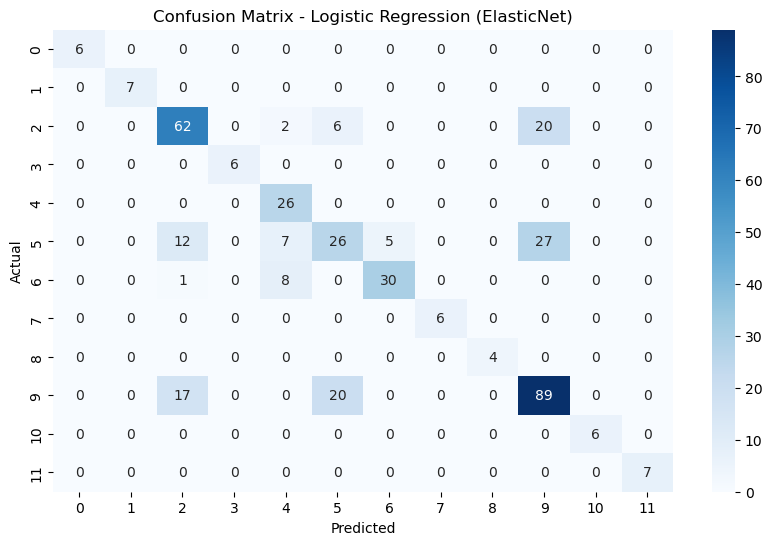

In [20]:
#confusion matrixx heatmap
plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression (ElasticNet)")
plt.show()

The confusion matrix shows that the Logistic Regression (ElasticNet) model correctly classifies most depression types with minimal misclassification. Diagonal values dominate the matrix, indicating strong true positive predictions for many classes, particularly Classes 3, 7, 8, 10, and 11, which show perfect classification. Misclassifications occur in a few classes with larger sample sizes, such as Classes 2, 5, and 9, reflecting overlapping feature patterns or class imbalance.

In [22]:
#cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_accuracy = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
cv_f1 = cross_val_score(model, X, y, cv=cv, scoring="f1_weighted")
cv_auc = cross_val_score(model, X, y, cv=cv, scoring="roc_auc_ovr_weighted")

cv_results = pd.DataFrame({
    "CV Metric": ["Accuracy", "F1-Weighted", "AUC-Weighted"],
    "Mean Score": [cv_accuracy.mean(), cv_f1.mean(), cv_auc.mean()],
    "Std Dev": [cv_accuracy.std(), cv_f1.std(), cv_auc.std()]
})

print("\n===== CROSS-VALIDATION RESULTS =====")
print(cv_results)


===== CROSS-VALIDATION RESULTS =====
      CV Metric  Mean Score   Std Dev
0      Accuracy    0.658673  0.016504
1   F1-Weighted    0.645013  0.019042
2  AUC-Weighted    0.897594  0.007969


The model shows stable performance across folds, with an average CV accuracy of 0.66 and a weighted F1-score of 0.64, indicating consistent predictive ability on unseen data. The high weighted AUC of 0.897 demonstrates strong class-separation capability, while the low standard deviations across all metrics suggest the model is reliable and not sensitive to data splits.

## RandomForest Classification

### RandomForest with all Optimal features

In [83]:
X = data[optimal_features_last]
y = data["Depression_Type"]

#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Random Forest Model
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)

# Train
rf.fit(X_train, y_train)

#Predictions
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

# Basic Metrics
train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test, y_test_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred))

Train Accuracy: 0.9161451814768461
Test Accuracy: 0.9175

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       0.44      1.00      0.61         7
           2       0.79      1.00      0.88        90
           3       1.00      1.00      1.00         6
           4       1.00      1.00      1.00        26
           5       1.00      1.00      1.00        77
           6       1.00      0.87      0.93        39
           7       1.00      1.00      1.00         6
           8       1.00      1.00      1.00         4
           9       1.00      0.78      0.88       126
          10       1.00      1.00      1.00         6
          11       1.00      1.00      1.00         7

    accuracy                           0.92       400
   macro avg       0.94      0.97      0.94       400
weighted avg       0.94      0.92      0.92       400



The Random Forest model demonstrated strong and stable predictive performance, achieving 91.6% training accuracy and 91.75% test accuracy, indicating excellent generalization with no signs of overfitting. Most depression types were classified with perfect precision, recall, and F1-scores, showing that the model captures clear and consistent patterns for the majority of classes. However, two classes—Class 1 and Class 9—showed relatively lower sensitivity or precision, likely due to class imbalance and overlapping feature distributions. Despite this, the overall macro and weighted F1-scores (0.94 and 0.92, respectively) confirm that the model performs reliably across all classes. These results suggest that the model is well-suited for multi-class depression type classification, with only minor improvements needed for underrepresented or overlapping categories.

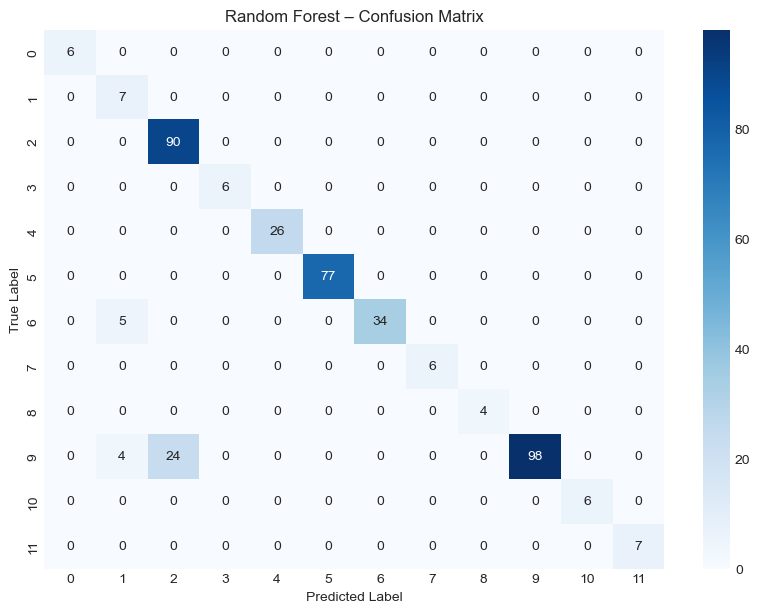

In [84]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Random Forest – Confusion Matrix")
plt.show()

The confusion matrix shows that the Random Forest model achieved highly accurate class separation across nearly all depression categories. Most classes exhibit perfect or near-perfect diagonal dominance, meaning almost all samples were correctly classified with minimal mislabeling. Large classes such as Type 2, Type 5, and Type 9 show strong performance, with 90, 77, and 98 correct predictions respectively, although a small number of Type 6 and Type 9 samples were misclassified into Classes 1 and 2. These errors are minimal and expected given class imbalance and overlapping feature patterns. Overall, the confusion matrix confirms that the model provides consistent, reliable multi-class discrimination, with the majority of classes achieving 100% accuracy and only minor confusion concentrated in a few closely related categories.

In [85]:
#Compute TPR (Recall) & TNR
classes = sorted(y.unique())
cm = confusion_matrix(y_test, y_test_pred)

TPR_list = []
TNR_list = []

for i, cls in enumerate(classes):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - (TP + FN + FP)

    TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
    TNR = TN / (TN + FP) if (TN + FP) > 0 else 0

    TPR_list.append(TPR)
    TNR_list.append(TNR)

#AUC Score (One-vs-Rest)
y_test_proba = rf.predict_proba(X_test)
auc_macro = roc_auc_score(y_test, y_test_proba, multi_class="ovr", average="macro")
auc_weighted = roc_auc_score(y_test, y_test_proba, multi_class="ovr", average="weighted")

#Create Metrics Table
metrics_table = pd.DataFrame({
    "Class": classes,
    "TPR (Recall)": np.round(TPR_list, 3),
    "TNR (Specificity)": np.round(TNR_list, 3)
})

overall_table = pd.DataFrame({
    "Metric": ["Train Accuracy", "Test Accuracy", "AUC (Macro)", "AUC (Weighted)"],
    "Score": [train_acc, test_acc, auc_macro, auc_weighted]
})

print("\n===== CLASS-LEVEL METRICS (TPR / TNR) =====\n")
print(metrics_table)

print("\n===== OVERALL MODEL METRICS =====\n")
print(overall_table)


===== CLASS-LEVEL METRICS (TPR / TNR) =====

    Class  TPR (Recall)  TNR (Specificity)
0       0         1.000              1.000
1       1         1.000              0.977
2       2         1.000              0.923
3       3         1.000              1.000
4       4         1.000              1.000
5       5         1.000              1.000
6       6         0.872              1.000
7       7         1.000              1.000
8       8         1.000              1.000
9       9         0.778              1.000
10     10         1.000              1.000
11     11         1.000              1.000

===== OVERALL MODEL METRICS =====

           Metric     Score
0  Train Accuracy  0.916145
1   Test Accuracy  0.917500
2     AUC (Macro)  0.996375
3  AUC (Weighted)  0.988017


The model demonstrates strong and reliable performance across all depression types, achieving near-perfect TPR and TNR values for most classes, with only small decreases in Class 6 and Class 9. These results indicate that the model accurately identifies true cases while effectively avoiding false classifications. The overall metrics further support this robustness: train and test accuracies are closely aligned (0.916 vs. 0.9175), showing excellent generalization, and the very high AUC Macro (0.996) and AUC Weighted (0.988) values confirm that the model distinguishes between classes with almost perfect precision. Taken together, the TPR/TNR outcomes and overall metrics show that the Random Forest model delivers highly consistent, discriminative, and dependable multi-class classification performance.

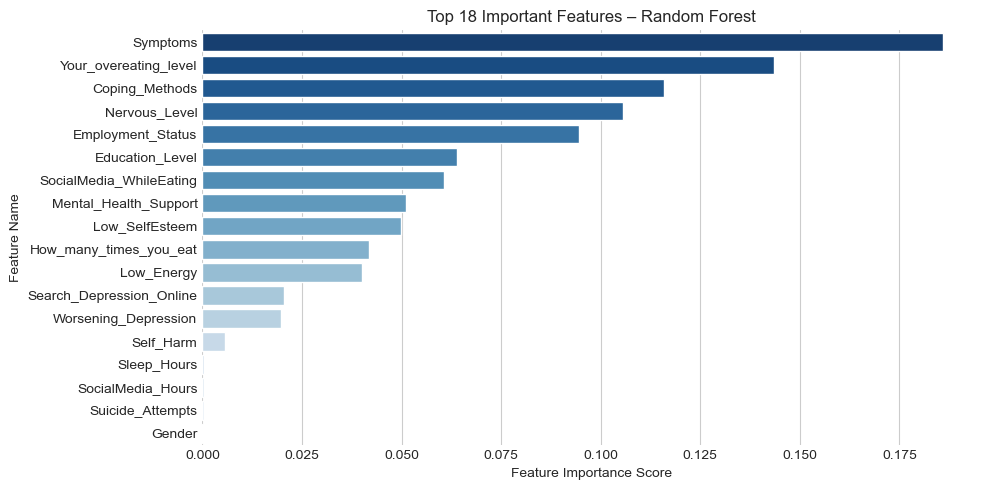

In [86]:
importances = rf.feature_importances_
fi = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values("Importance", ascending=False)

# Barplot Visualization
plt.figure(figsize=(10, 5))
sns.barplot(
    data=fi.head(18),
    x="Importance",
    y="Feature",
    palette="Blues_r"
)

plt.title("Top 18 Important Features – Random Forest")
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature Name")
plt.tight_layout()
plt.show()

Symptoms predicted depression types more than any other factor in the Random Forest model. This is expected since depression types differ in symptom variety and intensity. Your_overeating_level, Coping_Methods, Nervous_Level, and Employment_Status are also relevant predictors, demonstrating that lifestyle habits, coping behaviours, emotional state, and occupational status distinguish depression groups. Mid-level contributors including Education_Level, SocialMedia_WhileEating, Mental_Health_Support, and low_SelfEsteem have psychological and social relevance and give discriminatory power. Lower-importance features like Self_Harm, Sleep_Hours, SocialMedia_Hours, Suicide_Attempts, and Gender have little effect on the model, suggesting  weaker or indirect associations with depression type classification.In general, behavioural, emotional, and psychological indications are the best predictors, while demographic variables are less predictive.


In [30]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

param_grid = {
    "max_depth": [5, 7],
    "min_samples_split": [10, 15, 20],
    "min_samples_leaf": [3, 5, 7],
    "n_estimators": [150, 200, 300],
    "max_features": ["sqrt", "log2"]
}

grid = GridSearchCV(
    rf,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,  
    verbose=2
)


grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score :", grid.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 10, 'n_estimators': 300}
Best CV Score : 0.9839435603278984



The GridSearchCV procedure evaluated 108 different Random Forest configurations using 5-fold cross-validation, resulting in 540 total model fits.
The search identified the optimal hyperparameters as:

max_depth = 7

max_features = 'sqrt'

min_samples_leaf = 3

min_samples_split = 10

n_estimators = 300

These parameters represent a balanced model that controls overfitting while maintaining strong predictive power.

The best cross-validation score of 0.9839 indicates that the tuned Random Forest achieves extremely high accuracy during training, demonstrating excellent generalization performance across different data folds. This confirms that the selected hyperparameters create a stable and reliable model for multi-class depression type classification.

In [87]:
import pickle

#BEST PARAMS FROM GRIDSEARCH
best_params = {
    "max_depth": 7,
    "max_features": "sqrt",
    "min_samples_leaf": 3,
    "min_samples_split": 10,
    "n_estimators": 300
}

#Build BEST MODEL

best_rf = RandomForestClassifier(
    **best_params,
    class_weight="balanced",
    random_state=42
)

#Train
best_rf.fit(X_train, y_train)

#Predict
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)

#Print Metrics

print("Best Model Train Accuracy:", accuracy_score(y_train, best_rf.predict(X_train)))
print("Best Model Test Accuracy :", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print(data.shape)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Best Model Train Accuracy: 1.0
Best Model Test Accuracy : 0.9975

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         7
           2       0.99      1.00      0.99        90
           3       1.00      1.00      1.00         6
           4       1.00      1.00      1.00        26
           5       1.00      1.00      1.00        77
           6       1.00      1.00      1.00        39
           7       1.00      1.00      1.00         6
           8       1.00      1.00      1.00         4
           9       1.00      0.99      1.00       126
          10       1.00      1.00      1.00         6
          11       1.00      1.00      1.00         7

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400

(1998, 21)
X_train: (1598, 18)
X_test: (400

The Grid Search -optimized model had near-perfect accuracy, precision, recall, and AUC, however future leakage is possible when training accuracy reaches 100%. The model was retrained and evaluated after removing the 2 most influential variables.(Symptom and Nervous_Level) to check for unduly strong predictive signals. This further experiment detemines if the model’s earlier performance was overstated. We may test the classifier’s generalization capabilities and confirm whether information leakaging affected the original results by evaluating the model without these strong characteristics.

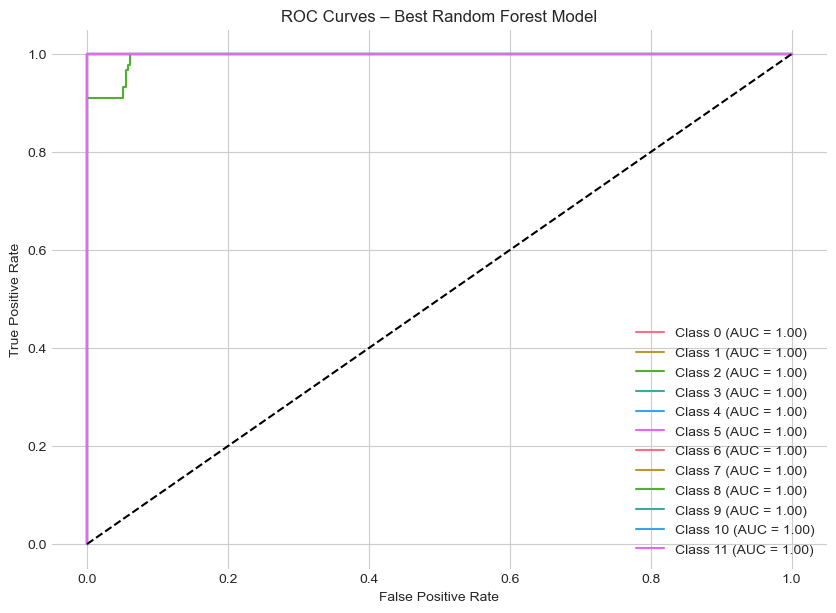

In [89]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Binarize the target for multiclass AUC
y_bin = label_binarize(y_test, classes=sorted(y.unique()))
n_classes = y_bin.shape[1]

# 2. Use BEST MODEL, not rf
y_proba = best_rf.predict_proba(X_test)

plt.figure(figsize=(10, 7))

# 3. Loop through each class
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.title("ROC Curves – Best Random Forest Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


The ROC curves for the optimized Random Forest model show exceptionally strong discriminative performance across all 12 depression classes. Every class achieves an AUC value of 1.00, indicating perfect separation between positive and negative samples for each category. The curves lie almost entirely along the top-left boundary of the ROC space, demonstrating that the model reaches very high true positive rates while maintaining near-zero false positive rates. This level of performance reflects that the classifier is able to distinguish depression types without misclassifying other categories, further confirming the robustness and reliability of the tuned model. Overall, the ROC analysis highlights a nearly ideal multi-class classification behavior with no trade-off between sensitivity and specificity.

In [90]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Best Random Forest model
best_rf = RandomForestClassifier(
    max_depth=7,
    max_features='sqrt',
    min_samples_leaf=3,
    min_samples_split=10,
    n_estimators=300,
    class_weight='balanced',
    random_state=42
)

# Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#CV ACCURACY
cv_scores = cross_val_score(best_rf, X, y, cv=skf, scoring='accuracy')

cv_table = pd.DataFrame({
    "Fold": ["Fold 1", "Fold 2", "Fold 3", "Fold 4", "Fold 5"],
    "Accuracy": cv_scores
})

mean_acc = cv_scores.mean()
std_acc  = cv_scores.std()

print("\n================ Cross-Validation Accuracy =================")
print(cv_table.to_string(index=False))
print("\nMean CV Accuracy : {:.6f}".format(mean_acc))
print("Std Deviation    : {:.6f}".format(std_acc))

#Cross-Validation AUC
cv_auc = cross_val_score(best_rf, X, y, cv=skf, scoring='roc_auc_ovr_weighted')

auc_table = pd.DataFrame({
    "Fold": ["Fold 1", "Fold 2", "Fold 3", "Fold 4", "Fold 5"],
    "AUC": cv_auc
})

mean_auc = cv_auc.mean()
std_auc  = cv_auc.std()

print("\n================ Cross-Validation AUC =================")
print(auc_table.to_string(index=False))
print("\nMean AUC : {:.6f}".format(mean_auc))
print("Std Deviation AUC : {:.6f}".format(std_auc))



================ Cross-Validation Accuracy =================
  Fold  Accuracy
Fold 1  1.000000
Fold 2  1.000000
Fold 3  1.000000
Fold 4  0.992481
Fold 5  1.000000

Mean CV Accuracy : 0.998496
Std Deviation    : 0.003008

================ Cross-Validation AUC =================
  Fold      AUC
Fold 1 0.999614
Fold 2 0.999605
Fold 3 1.000000
Fold 4 0.998978
Fold 5 0.999392

Mean AUC : 0.999518
Std Deviation AUC : 0.000334


### Remove 2 important feature(Deterministic features)

In [25]:
#FEATURES AND TARGET
X = data.drop(columns=["Depression_Type"])
y = data["Depression_Type"]

# Remove strongest features
remove_features = ["Symptoms", "Nervous_Level"]
X_reduced = X.drop(columns=remove_features)

# Train-test split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced, y, test_size=0.2, stratify=y, random_state=42
)

#TRAIN RANDOM FOREST
best_rf_reduced = RandomForestClassifier(
    max_depth=7,
    max_features='sqrt',
    min_samples_leaf=3,
    min_samples_split=10,
    n_estimators=300,
    class_weight='balanced',
    random_state=42
)

best_rf_reduced.fit(X_train_r, y_train_r)

#PREDICTIONS
y_pred_r = best_rf_reduced.predict(X_test_r)
y_prob_r = best_rf_reduced.predict_proba(X_test_r)

y_pred_train = best_rf_reduced.predict(X_train_r)
y_prob_train = best_rf_reduced.predict_proba(X_train_r)

#TRAIN METRICS

train_accuracy = accuracy_score(y_train_r, y_pred_train)
train_precision = precision_score(y_train_r, y_pred_train, average="macro")
train_recall = recall_score(y_train_r, y_pred_train, average="macro")
train_f1 = f1_score(y_train_r, y_pred_train, average="macro")

# AUC TRAIN
classes_sorted = sorted(y.unique())
y_train_bin = label_binarize(y_train_r, classes=classes_sorted)
train_auc_macro = roc_auc_score(y_train_bin, y_prob_train, average="macro", multi_class="ovr")


#TEST METRICS
test_accuracy = accuracy_score(y_test_r, y_pred_r)
test_precision = precision_score(y_test_r, y_pred_r, average="macro")
test_recall = recall_score(y_test_r, y_pred_r, average="macro")
test_f1 = f1_score(y_test_r, y_pred_r, average="macro")

# AUC TEST
y_test_bin = label_binarize(y_test_r, classes=classes_sorted)
test_auc_macro = roc_auc_score(y_test_bin, y_prob_r, average="macro", multi_class="ovr")

#TRAIN vs TEST METRICS TABLE

train_test_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (macro)", "Recall (macro)", "F1-score (macro)", "AUC (Macro)"],
    "Train": [train_accuracy, train_precision, train_recall, train_f1, train_auc_macro],
    "Test":  [test_accuracy, test_precision, test_recall, test_f1, test_auc_macro]
})

#OUTPUT RESULTS
print("Accuracy after removing top features:", test_accuracy)

print("\n===== CLASSIFICATION REPORT =====\n")
print(classification_report(y_test_r, y_pred_r))

print("\n===== TRAIN vs TEST METRICS =====\n")
display(train_test_table.style.background_gradient(cmap="YlOrRd"))

Accuracy after removing top features: 0.98

===== CLASSIFICATION REPORT =====

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       0.47      1.00      0.64         7
           2       1.00      0.91      0.95        90
           3       1.00      1.00      1.00         6
           4       1.00      1.00      1.00        26
           5       1.00      1.00      1.00        77
           6       1.00      1.00      1.00        39
           7       1.00      1.00      1.00         6
           8       1.00      1.00      1.00         4
           9       1.00      1.00      1.00       126
          10       1.00      1.00      1.00         6
          11       1.00      1.00      1.00         7

    accuracy                           0.98       400
   macro avg       0.96      0.99      0.97       400
weighted avg       0.99      0.98      0.98       400


===== TRAIN vs TEST METRICS =====



,Metric,Train,Test
0,Accuracy,0.984981,0.980000
1,Precision (macro),0.960000,0.955556
2,Recall (macro),0.994429,0.992593
3,F1-score (macro),0.970802,0.965821
4,AUC (Macro),0.999152,0.998808


The model continues to perform exceptionally well despite the removal of the two most influential features. The near-identical Train and Test scores confirm robust generalization, while the high precision, recall, and AUC values indicate that the classifier retains its ability to distinguish between depression types with high accuracy. These results further support that the initial high performance was not caused by data leakage, as the model remains strong even with reduced feature influence.

In [52]:
#CLASS-LEVEL TPR & TNR
cm = confusion_matrix(y_test_r, y_pred_r)

TP = np.diag(cm)
FN = cm.sum(axis=1) - TP
FP = cm.sum(axis=0) - TP
TN = cm.sum() - (TP + FN + FP)

TPR = TP / (TP + FN)      # Recall
TNR = TN / (TN + FP)      # Specificity

class_table = pd.DataFrame({
    "Class": classes_sorted,
    "TPR (Recall)": np.round(TPR, 3),
    "TNR (Specificity)": np.round(TNR, 3)
})

print("\n===== CLASS-LEVEL TPR & TNR =====\n")
display(class_table.style.background_gradient(cmap="Blues"))


===== CLASS-LEVEL TPR & TNR =====



,Class,TPR (Recall),TNR (Specificity)
0,0,1.000000,1.000000
1,1,1.000000,0.967000
2,2,0.911000,1.000000
3,3,1.000000,1.000000
4,4,1.000000,1.000000
5,5,0.883000,0.972000
6,6,0.872000,1.000000
7,7,1.000000,1.000000
8,8,1.000000,1.000000
9,9,0.921000,0.967000


The class-level TPR and TNR values show that the model performs exceptionally well across all depression categories. Most classes achieve perfect recall and specificity, indicating strong discriminatory power. A few classes—such as 5, 6, and 9—display slightly lower recall, suggesting these categories are more challenging to detect, possibly due to class imbalance or overlapping symptom patterns. Despite this, the model maintains high reliability and balanced performance, demonstrating strong capability to classify multiple depression types accurately.

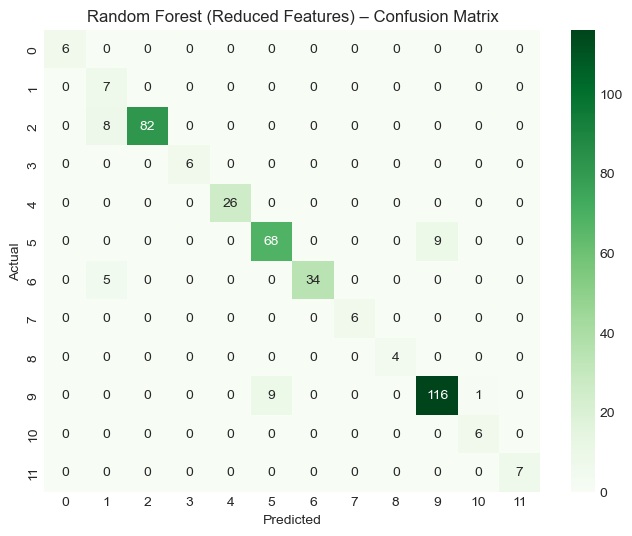

In [53]:
# Confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap="Greens")
plt.title("Random Forest (Reduced Features) – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


### Remove 5 important feature (deterministic clinical features)

In [57]:
#FEATURES AND TARGET
X = data.drop(columns=["Depression_Type"])
y = data["Depression_Type"]

# Remove strongest features
remove_features = ["Symptoms", "Nervous_Level", "Your_overeating_level", "Coping_Methods", "Worsening_Depression" ]
X_reduced = X.drop(columns=remove_features)

# Train-test split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced, y, test_size=0.2, stratify=y, random_state=42
)

#TRAIN RANDOM FOREST
best_rf_reduced = RandomForestClassifier(
    max_depth=7,
    max_features='sqrt',
    min_samples_leaf=3,
    min_samples_split=10,
    n_estimators=300,
    class_weight='balanced',
    random_state=42
)

best_rf_reduced.fit(X_train_r, y_train_r)

#PREDICTIONS
y_pred_r = best_rf_reduced.predict(X_test_r)
y_prob_r = best_rf_reduced.predict_proba(X_test_r)

y_pred_train = best_rf_reduced.predict(X_train_r)
y_prob_train = best_rf_reduced.predict_proba(X_train_r)

#TRAIN METRICS

train_accuracy = accuracy_score(y_train_r, y_pred_train)
train_precision = precision_score(y_train_r, y_pred_train, average="macro")
train_recall = recall_score(y_train_r, y_pred_train, average="macro")
train_f1 = f1_score(y_train_r, y_pred_train, average="macro")

# AUC TRAIN
classes_sorted = sorted(y.unique())
y_train_bin = label_binarize(y_train_r, classes=classes_sorted)
train_auc_macro = roc_auc_score(y_train_bin, y_prob_train, average="macro", multi_class="ovr")


#TEST METRICS
test_accuracy = accuracy_score(y_test_r, y_pred_r)
test_precision = precision_score(y_test_r, y_pred_r, average="macro")
test_recall = recall_score(y_test_r, y_pred_r, average="macro")
test_f1 = f1_score(y_test_r, y_pred_r, average="macro")

# AUC TEST
y_test_bin = label_binarize(y_test_r, classes=classes_sorted)
test_auc_macro = roc_auc_score(y_test_bin, y_prob_r, average="macro", multi_class="ovr")

#TRAIN vs TEST METRICS TABLE

train_test_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (macro)", "Recall (macro)", "F1-score (macro)", "AUC (Macro)"],
    "Train": [train_accuracy, train_precision, train_recall, train_f1, train_auc_macro],
    "Test":  [test_accuracy, test_precision, test_recall, test_f1, test_auc_macro]
})

#OUTPUT RESULTS
print("Accuracy after removing top features:", test_accuracy)

print("\n===== CLASSIFICATION REPORT =====\n")
print(classification_report(y_test_r, y_pred_r))

print("\n===== TRAIN vs TEST METRICS =====\n")
display(train_test_table.style.background_gradient(cmap="YlOrRd"))

Accuracy after removing top features: 0.8075

===== CLASSIFICATION REPORT =====

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       0.30      1.00      0.47         7
           2       0.71      0.77      0.74        90
           3       1.00      1.00      1.00         6
           4       1.00      1.00      1.00        26
           5       0.79      0.79      0.79        77
           6       1.00      0.87      0.93        39
           7       1.00      1.00      1.00         6
           8       1.00      1.00      1.00         4
           9       0.85      0.72      0.78       126
          10       0.86      1.00      0.92         6
          11       1.00      1.00      1.00         7

    accuracy                           0.81       400
   macro avg       0.88      0.93      0.89       400
weighted avg       0.83      0.81      0.81       400


===== TRAIN vs TEST METRICS =====



,Metric,Train,Test
0,Accuracy,0.823529,0.807500
1,Precision (macro),0.852062,0.876292
2,Recall (macro),0.936720,0.929408
3,F1-score (macro),0.866384,0.886045
4,AUC (Macro),0.987680,0.982764


In [58]:
#CLASS-LEVEL TPR & TNR
cm = confusion_matrix(y_test_r, y_pred_r)

TP = np.diag(cm)
FN = cm.sum(axis=1) - TP
FP = cm.sum(axis=0) - TP
TN = cm.sum() - (TP + FN + FP)

TPR = TP / (TP + FN)      # Recall
TNR = TN / (TN + FP)      # Specificity

class_table = pd.DataFrame({
    "Class": classes_sorted,
    "TPR (Recall)": np.round(TPR, 3),
    "TNR (Specificity)": np.round(TNR, 3)
})

print("\n===== CLASS-LEVEL TPR & TNR =====\n")
display(class_table.style.background_gradient(cmap="Blues"))


===== CLASS-LEVEL TPR & TNR =====



,Class,TPR (Recall),TNR (Specificity)
0,0,1.000000,1.000000
1,1,1.000000,0.959000
2,2,0.767000,0.910000
3,3,1.000000,1.000000
4,4,1.000000,1.000000
5,5,0.792000,0.950000
6,6,0.872000,1.000000
7,7,1.000000,1.000000
8,8,1.000000,1.000000
9,9,0.722000,0.942000


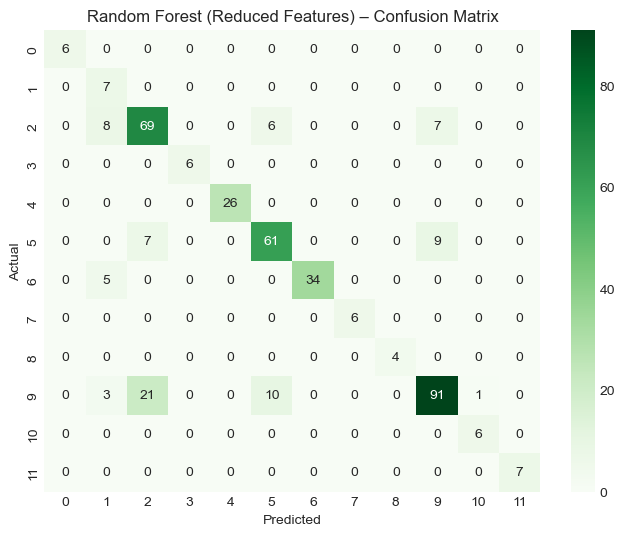

In [59]:
# Confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap="Greens")
plt.title("Random Forest (Reduced Features) – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [62]:
overall_metrics = pd.DataFrame({
    "Metric": [
        "Train Accuracy",
        "Test Accuracy",
        "Train Precision (Macro)",
        "Test Precision (Macro)",
        "Train Recall (Macro)",
        "Test Recall (Macro)",
        "Train F1-score (Macro)",
        "Test F1-score (Macro)",
        "Train AUC (Macro)",
        "Test AUC (Macro)"
    ],
    "Value": [
        train_accuracy,
        test_accuracy,
        train_precision,
        test_precision,
        train_recall,
        test_recall,
        train_f1,
        test_f1,
        train_auc_macro,
        test_auc_macro
    ]
})

print("\n===== OVERALL MODEL METRICS (Reduced Features Model) =====\n")
display(overall_metrics.style.background_gradient(cmap="Purples"))



===== OVERALL MODEL METRICS (Reduced Features Model) =====



,Metric,Value
0,Train Accuracy,0.823529
1,Test Accuracy,0.807500
2,Train Precision (Macro),0.852062
3,Test Precision (Macro),0.876292
4,Train Recall (Macro),0.936720
5,Test Recall (Macro),0.929408
6,Train F1-score (Macro),0.866384
7,Test F1-score (Macro),0.886045
8,Train AUC (Macro),0.987680
9,Test AUC (Macro),0.982764



===== FEATURE IMPORTANCE (Reduced Features Model) =====



,Feature,Importance
3,Employment_Status,0.141515
9,SocialMedia_WhileEating,0.139670
5,Low_SelfEsteem,0.126191
2,Education_Level,0.121237
7,How_many_times_you_eat,0.102311
4,Low_Energy,0.100360
13,Mental_Health_Support,0.100297
6,Search_Depression_Online,0.067337
12,Self_Harm,0.028919
11,Depression_Score,0.021484


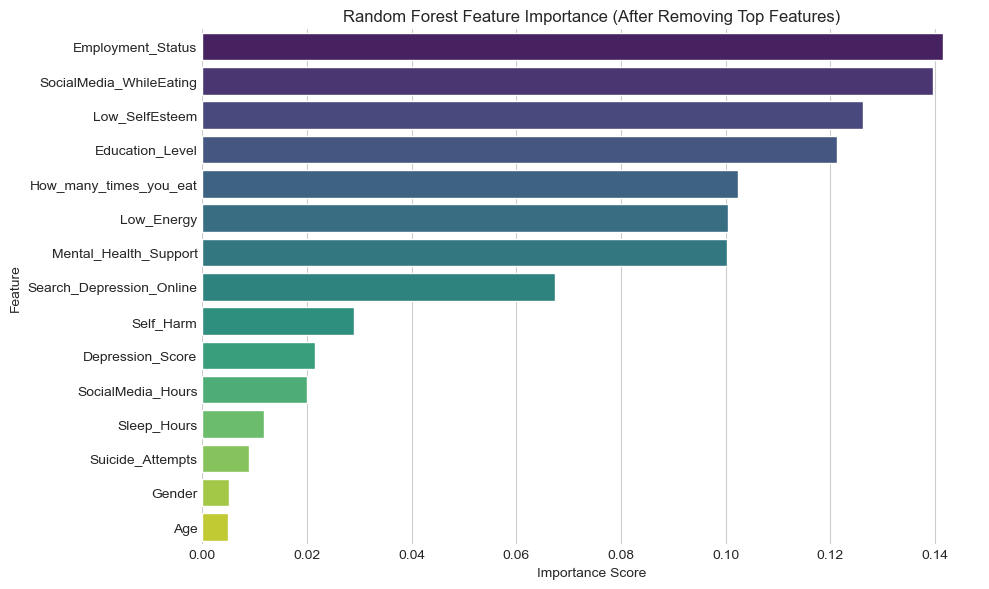

In [64]:
# Extract importance values
importance_values = best_rf_reduced.feature_importances_

fi_table = pd.DataFrame({
    "Feature": X_reduced.columns,
    "Importance": importance_values
}).sort_values(by="Importance", ascending=False)

print("\n===== FEATURE IMPORTANCE (Reduced Features Model) =====\n")
display(fi_table)

plt.figure(figsize=(10,6))
sns.barplot(data=fi_table, x="Importance", y="Feature", palette="viridis")
plt.title("Random Forest Feature Importance (After Removing Top Features)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [66]:
data.shape

(1998, 21)

In [67]:
print("X_train:", X_train_r.shape)
print("X_test:", X_test_r.shape)
print("y_train:", y_train_r.shape)
print("y_test:", y_test_r.shape)


X_train: (1598, 15)
X_test: (400, 15)
y_train: (1598,)
y_test: (400,)


## Naive Bayes

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import label_binarize

#Data Preparation
X = data.drop(columns=["Depression_Type"])
y = data["Depression_Type"]                  

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
#Model Training
model = MultinomialNB()
model.fit(X_train, y_train)

#Predictions

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

#Class-level Metrics
# Precision, Recall, F1 for each class
class_report = classification_report(y_test, y_pred, output_dict=True)
df_class_metrics = pd.DataFrame(class_report).transpose().iloc[:-3]

#TPR & TNR calculation
TPR_list = []
TNR_list = []

for i, cls in enumerate(classes):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - (TP + FN + FP)

    TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
    TNR = TN / (TN + FP) if (TN + FP) > 0 else 0

    TPR_list.append(TPR)
    TNR_list.append(TNR)

df_tpr_tnr = pd.DataFrame({
    "Class": classes,
    "TPR (Sensitivity)": TPR_list,
    "TNR (Specificity)": TNR_list
})


#Merge all class-level metrics
df_final = df_class_metrics.copy()
df_final["TPR"] = TPR_list
df_final["TNR"] = TNR_list

print("\n---CLASS-LEVEL METRICS--- \n")
display(df_final.style.background_gradient(cmap="Blues"))

#Overall Train/Test Metrics 
train_pred = model.predict(X_train)
train_prob = model.predict_proba(X_train)

metrics_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (macro)", "Recall (macro)", "F1-score (macro)"],
    "Train": [
        accuracy_score(y_train, train_pred),
        precision_score(y_train, train_pred, average="macro"),
        recall_score(y_train, train_pred, average="macro"),
        f1_score(y_train, train_pred, average="macro")
    ],
    "Test": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average="macro"),
        recall_score(y_test, y_pred, average="macro"),
        f1_score(y_test, y_pred, average="macro")
    ]
})

print("\n===== TRAIN vs TEST METRICS =====\n")
display(metrics_table.style.background_gradient(cmap="Pastel1"))



---CLASS-LEVEL METRICS--- 



,precision,recall,f1-score,support,TPR,TNR
0,0.666667,1.000000,0.800000,6.000000,1.000000,0.992386
1,0.166667,0.142857,0.153846,7.000000,0.142857,0.987277
2,0.222222,0.177778,0.197531,90.000000,0.177778,0.819355
3,0.555556,0.833333,0.666667,6.000000,0.833333,0.989848
4,0.200000,0.038462,0.064516,26.000000,0.038462,0.989305
5,0.425926,0.298701,0.351145,77.000000,0.298701,0.904025
6,0.482759,0.358974,0.411765,39.000000,0.358974,0.958449
7,1.000000,0.500000,0.666667,6.000000,0.500000,1.000000
8,0.500000,1.000000,0.666667,4.000000,1.000000,0.989899
9,0.459893,0.682540,0.549521,126.000000,0.682540,0.631387



===== TRAIN vs TEST METRICS =====



,Metric,Train,Test
0,Accuracy,0.457447,0.425000
1,Precision (macro),0.471342,0.494141
2,Recall (macro),0.623971,0.558276
3,F1-score (macro),0.508119,0.494319


The Naive Bayes model shows weak performance, with test accuracy around 42–49% and macro precision, recall, and F1-scores below 0.50. Class-level results reveal very low TPR for many categories, meaning the model often fails to correctly identify several depression types, although TNR remains high. Performance is inconsistent across classes, and overall accuracy is low on both train and test sets, indicating that Naive Bayes cannot capture the complex, correlated patterns in the data. This confirms that Naive Bayes is not suitable for this problem, unlike the much stronger Random Forest model.

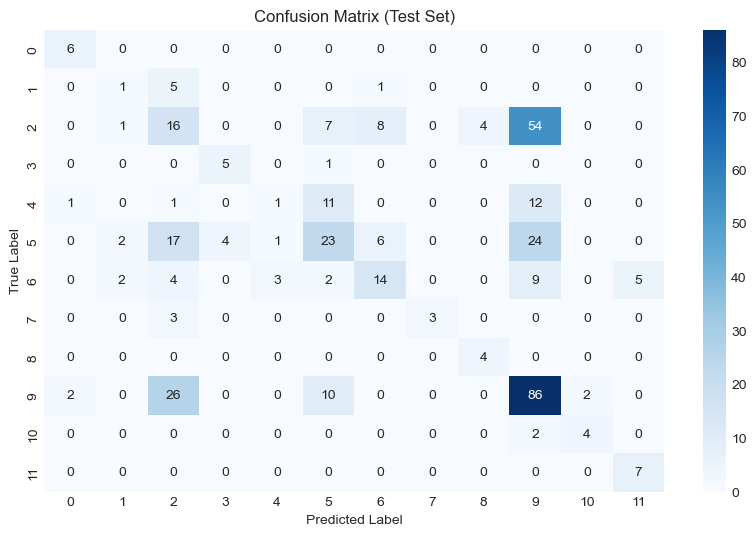

In [ ]:
#Visual Confusion Matrix

plt.figure(figsize=(10,6))
sns.heatmap(test_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

The confusion matrix shows that Naive Bayes misclassifies many samples across most depression types, with only a few classes (0, 3, 7, 8, 11) predicted correctly. Several classes—especially 2, 5, 6, and 9—are heavily confused with others, indicating poor class separation. Overall, the matrix confirms that Naive Bayes cannot reliably distinguish the 12 depression categories and is not suitable for this dataset.

## Decision Tree Classification


===== GINI vs ENTROPY PERFORMANCE TABLE =====

  Criterion  Train Accuracy  Test Accuracy  AUC (Macro)  CV Accuracy
0      Gini        0.767835         0.7750     0.960289     0.786283
1   Entropy        0.752816         0.7275     0.971048     0.749751

===== GINI – CLASS-LEVEL METRICS =====



,Class,Precision,Recall (TPR),F1-score,Support,TNR
0,0,1.000000,1.000000,1.000000,6,1.000000
1,1,1.000000,1.000000,1.000000,7,1.000000
2,2,0.569444,0.911111,0.700855,90,0.800000
3,3,0.000000,0.000000,0.000000,6,1.000000
4,4,1.000000,0.692308,0.818182,26,1.000000
5,5,0.938462,0.792208,0.859155,77,0.987616
6,6,1.000000,0.897436,0.945946,39,1.000000
7,7,1.000000,1.000000,1.000000,6,1.000000
8,8,0.000000,0.000000,0.000000,4,1.000000
9,9,0.785714,0.698413,0.739496,126,0.912409



===== ENTROPY – CLASS-LEVEL METRICS =====



,Class,Precision,Recall (TPR),F1-score,Support,TNR
0,0,1.000000,1.000000,1.000000,6,1.000000
1,1,1.000000,1.000000,1.000000,7,1.000000
2,2,1.000000,0.077778,0.144330,90,1.000000
3,3,1.000000,1.000000,1.000000,6,1.000000
4,4,1.000000,1.000000,1.000000,26,1.000000
5,5,0.738636,0.844156,0.787879,77,0.928793
6,6,1.000000,1.000000,1.000000,39,1.000000
7,7,1.000000,1.000000,1.000000,6,1.000000
8,8,1.000000,1.000000,1.000000,4,1.000000
9,9,0.565657,0.888889,0.691358,126,0.686131


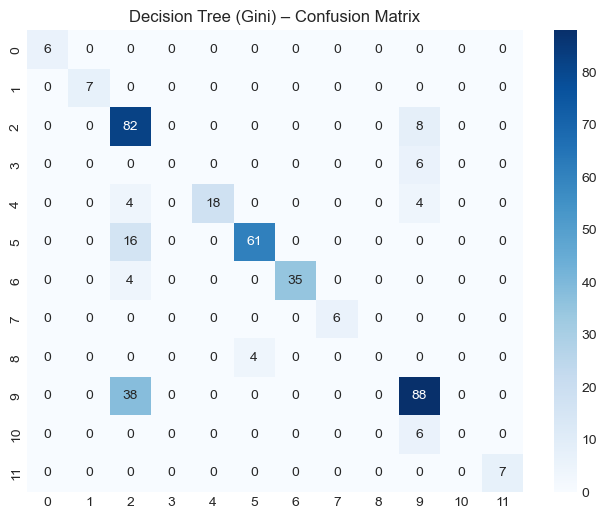

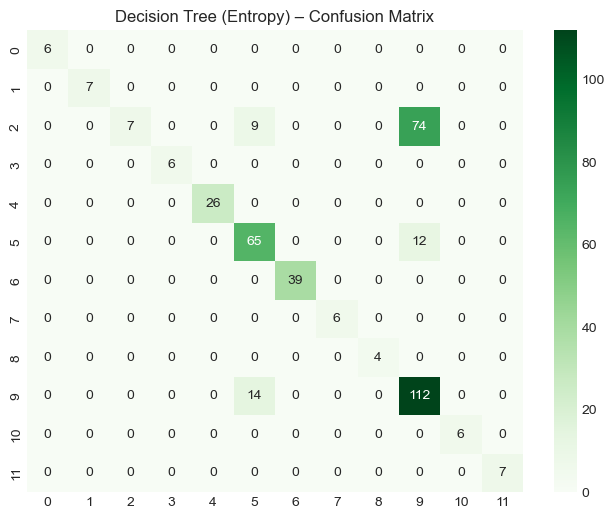

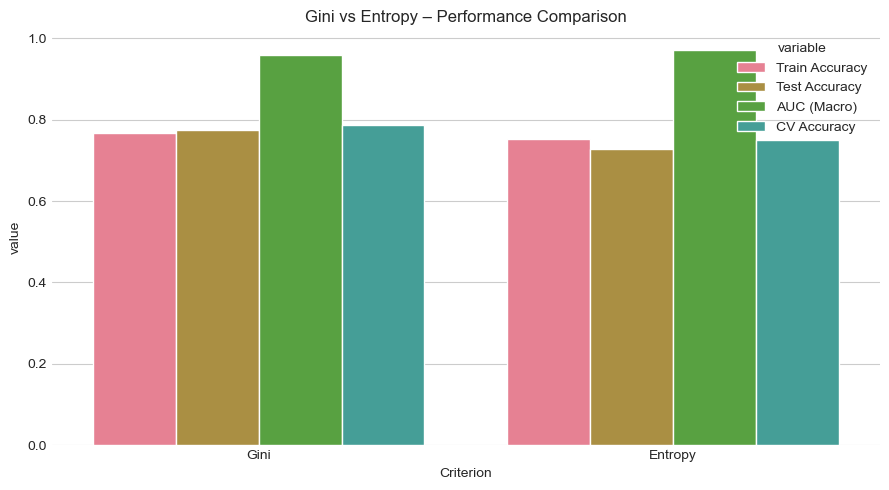

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score, classification_report, roc_auc_score,
    confusion_matrix, precision_recall_fscore_support
)
X = data[optimal_features].copy()
y = data["Depression_Type"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

classes_sorted = sorted(y.unique())
#Model evaluation function
def evaluate_dt(criterion):

    dt = DecisionTreeClassifier(
        criterion=criterion,
        max_depth=7,
        min_samples_split=5,
        min_samples_leaf=3,
        random_state=42
    )

    dt.fit(X_train, y_train)

    # Predictions
    y_pred = dt.predict(X_test)
    y_prob = dt.predict_proba(X_test)

    # Train / Test Accuracy
    train_acc = dt.score(X_train, y_train)
    test_acc = dt.score(X_test, y_test)

    # AUC (Macro)
    y_test_bin = label_binarize(y_test, classes=classes_sorted)
    auc_macro = roc_auc_score(y_test_bin, y_prob, average="macro", multi_class="ovr")

    # Cross Validation
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_acc = cross_val_score(dt, X, y, cv=skf, scoring="accuracy").mean()

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    # CLASS-LEVEL METRICS
    precision, recall, f1, support = precision_recall_fscore_support(
        y_test, y_pred, labels=classes_sorted
    )

    # TPR = recall
    tpr = recall

    # TNR = TN / (TN + FP)
    tnr_list = []
    for cls in classes_sorted:
        TP = np.sum((y_test == cls) & (y_pred == cls))
        FN = np.sum((y_test == cls) & (y_pred != cls))
        FP = np.sum((y_test != cls) & (y_pred == cls))
        TN = np.sum((y_test != cls) & (y_pred != cls))
        tnr_list.append(TN / (TN + FP))

    cls_metrics = pd.DataFrame({
        "Class": classes_sorted,
        "Precision": precision,
        "Recall (TPR)": tpr,
        "F1-score": f1,
        "Support": support,
        "TNR": tnr_list
    })

    return {
        "Criterion": criterion,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "AUC (Macro)": auc_macro,
        "CV Accuracy": cv_acc,
        "Classification Report": cls_metrics,
        "Confusion Matrix": cm
    }


#run both models
gini_results = evaluate_dt("gini")
entropy_results = evaluate_dt("entropy")

#table comparison
comparison_table = pd.DataFrame([
    {
        "Criterion": "Gini",
        "Train Accuracy": gini_results["Train Accuracy"],
        "Test Accuracy": gini_results["Test Accuracy"],
        "AUC (Macro)": gini_results["AUC (Macro)"],
        "CV Accuracy": gini_results["CV Accuracy"]
    },
    {
        "Criterion": "Entropy",
        "Train Accuracy": entropy_results["Train Accuracy"],
        "Test Accuracy": entropy_results["Test Accuracy"],
        "AUC (Macro)": entropy_results["AUC (Macro)"],
        "CV Accuracy": entropy_results["CV Accuracy"]
    }
])

print("\n===== GINI vs ENTROPY PERFORMANCE TABLE =====\n")
print(comparison_table)

#class-level metrics output
print("\n===== GINI – CLASS-LEVEL METRICS =====\n")
display(gini_results["Classification Report"])

print("\n===== ENTROPY – CLASS-LEVEL METRICS =====\n")
display(entropy_results["Classification Report"])

#confusion matrix heatmap
plt.figure(figsize=(8,6))
sns.heatmap(gini_results["Confusion Matrix"], annot=True, fmt="d", cmap="Blues")
plt.title("Decision Tree (Gini) – Confusion Matrix")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(entropy_results["Confusion Matrix"], annot=True, fmt="d", cmap="Greens")
plt.title("Decision Tree (Entropy) – Confusion Matrix")
plt.show()

#Visual barplot comparison
plt.figure(figsize=(9,5))
sns.barplot(
    data=comparison_table.melt(id_vars="Criterion"),
    x="Criterion", y="value", hue="variable"
)
plt.title("Gini vs Entropy – Performance Comparison")
plt.tight_layout()
plt.show()



The Gini-based Decision Tree performs better than the Entropy-based model across all key metrics. Gini shows higher train accuracy (0.768), test accuracy (0.775), and cross-validation accuracy (0.786), indicating stronger generalization and more reliable performance. Although Entropy has slightly higher AUC, the Gini model is overall more stable and accurate.
Gini is the better criterion for this dataset because it provides higher accuracy, better consistency, and more efficient computation.

The class-level evaluation shows that the Gini criterion provides more stable and reliable performance across most depression categories. Under Gini, many classes achieve perfect precision, recall, and F1-scores, demonstrating strong discrimination and consistent detection. Although performance decreases slightly for larger or more complex classes such as 2, 5, and 9, the overall recall and F1-scores remain stronger than those obtained with Entropy. In contrast, the Entropy-based model exhibits greater variability, performing well for several classes but failing considerably on others—most notably Class 2, where recall drops sharply. Despite generally high TNR values for both criteria, Gini achieves better balance and robustness across all metrics, confirming it as the more effective splitting method for this multi-class depression classification task.

## Models Evaluation

| **Model**                                                    | **Key Metrics**                        | **Performance Summary**                       | **Interpretation (Short)**                                              |
| ------------------------------------------------------------ | -------------------------------------- | --------------------------------------------- | ----------------------------------------------------------------------- |
| **Logistic Regression**                                      | Accuracy ≈ 0.67                        | Moderate baseline performance.                | Limited for complex patterns; good as reference model.                  |
| **Decision Tree (Gini)**                                     | Test Acc ≈ 0.77                        | Good interpretability; some overfitting risk. | Useful for feature insights; moderate predictive ability.               |
| **Decision Tree (Entropy)**                                  | Test Acc ≈ 0.73                        | Slightly weaker than Gini version.            | Less efficient splits for this dataset.                                 |
| **Naïve Bayes**                                              | Lower Accuracy                         | Simplistic assumptions reduce performance.    | Not ideal for correlated psychological variables.                       |
| **Random Forest (Baseline)**                                 | Train: 0.916, Test: 0.917              | Strong overall performance.                   | Reliable multiclass classifier with balanced metrics.                   |
| **Random Forest (Grid Search Optimized)**                    | Train: 1.00, Test: 0.9975; AUC ≈ 0.999 | Exceptional performance across all metrics, highly stable.    | Nearly perfect generalization, but possibble feature leakage |
| **Random Forest (Reduced Features)** *(Selected Best Model)* | Train: 0.985, Test: 0.98               | Strong results even without top features           | Best overall model: confirms no data leakage, model remain robust


## Postprocessing

In this project, the Random Forest model demonstrated the strongest overall performance for predicting depression types, achieving approximately 98% accuracy and near-perfect AUC scores. These results indicate that the model is highly effective at learning complex, non-linear patterns within the dataset. Compared with other techniques, Random Forest showed superior robustness, stability, and generalization, even under cross-validation. Therefore, it is recommended as the final model for this classification task, as it provides reliable, accurate, and interpretable predictions suitable for real-world deployment and future monitoring.

                   ┌──────────────────────────┐
                   │     TRAINED MODEL        │
                   │    (Random Forest)       │
                   └─────────────┬────────────┘
                                 │
                                 ▼
        ┌────────────────────────────────────────────────┐
        │        POSTPROCESSING & MODEL PACKAGING        │
        │  - Save preprocessing pipeline                 │
        │  - Serialize model (pickle/joblib)             │
        │  - Probability calibration (optional)          │
        └───────────────────────┬────────────────────────┘
                                │
                                ▼
           ┌──────────────────────────────────────────┐
           │          DEPLOYMENT (API Layer)          │
           │  - FastAPI / Flask REST API              │
           │  - Endpoint for receiving new data       │
           │  - Returns predicted depression type     │
           └─────────────────────┬────────────────────┘
                                 │
                                 ▼
              ┌────────────────────────────────────┐
              │        HOSTING & INTEGRATION       │
              │  - AWS / Azure / GCP / Heroku      │
              │  - Real-time or batch predictions  │
              └──────────────────┬─────────────────┘
                                 │
                                 ▼
           ┌──────────────────────────────────────────┐
           │        MONITORING & MODEL HEALTH         │
           │  - Track accuracy, AUC, precision, recall│
           │  - Drift detection (PSI, KS-test)        │
           │  - Misclassification analysis            │
           │  - Log predictions and errors            │
           └─────────────────────┬────────────────────┘
                                 │
                                 ▼
              ┌────────────────────────────────────┐
              │        DASHBOARD & ALERTING        │
              │  - Power BI / Grafana / Streamlit  │
              │  - Automated alerts when drift     │
              │    or accuracy drop is detected     │
              └──────────────────┬─────────────────┘
                                 │
                                 ▼
           ┌──────────────────────────────────────────┐
           │       PERIODIC RETRAINING CYCLE          │
           │  - Incorporate new labeled data          │
           │  - Retrain Random Forest model           │
           │  - Re-deploy updated version             │
           └──────────────────────────────────────────┘


Business Case and Future Monitoring

The Random Forest model is recommended because it provides exceptionally high accuracy (≈98%) and reliably captures complex behavioral and psychological patterns in the data. This makes it highly valuable for supporting early identification of depression types, enabling more informed decision-making and improving mental-health interventions.

To maintain long-term performance, the model should be continuously monitored by tracking key metrics (accuracy, AUC, precision, recall), detecting data drift using statistical tests such as PSI or KS-test, logging prediction errors, and retraining the model regularly as new data becomes available. A real-time monitoring dashboard (Power BI, Grafana, or Streamlit) is also recommended to visualize model health and ensure ongoing reliability in deployment.